# Laboratorio 6 - K Nearest Neighbors (KNN)

**CC3074 – Minería de Datos | UVG | Semestre I – 2026**

SmartStay Advisors: Predicción y clasificación de precios de Airbnb usando KNN.

In [30]:
%pip install rdata --quiet --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [31]:
import warnings
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import rdata

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, precision_score, recall_score, f1_score,
)

warnings.filterwarnings("ignore")
np.random.seed(42)

%matplotlib inline

## Carga y preparación de datos

Se replica exactamente el mismo pipeline de limpieza y preparación del lab 5 para garantizar que los conjuntos de entrenamiento y prueba sean idénticos y los modelos sean comparables.

In [32]:
parsed = rdata.parser.parse_file("listings.RData")
converted = rdata.conversion.convert(parsed)
df = list(converted.values())[0]

# Convertir nombres de columna y columnas string[python] a tipos nativos
# (rdata usa np.str_ y StringDtype que sklearn no reconoce)
df.columns = [str(c) for c in df.columns]
for col in df.columns:
    if pd.api.types.is_string_dtype(df[col]):
        df[col] = df[col].astype(object)

print(f"Dataset original: {df.shape[0]:,} filas, {df.shape[1]} columnas")
df.head()

Dataset original: 171,748 filas, 80 columnas


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city
1,5456.0,https://www.airbnb.com/rooms/5456,2.025092e+13,2025-09-17,city scrape,"Walk to 6th, Rainey St and Convention Ctr",Great central location for walking to Convent...,My neighborhood is ideally located if you want...,https://a0.muscache.com/pictures/14084884/b5a3...,8028,...,4.73,4.79,None,f,1,1,0,0,3.52,"Austin, Texas"
2,6448.0,https://www.airbnb.com/rooms/6448,2.025092e+13,2025-09-17,city scrape,"Secluded Studio @ Zilker - King Bed, Bright & ...","Clean, private space with everything you need ...",The neighborhood is fun and funky (but quiet)!...,https://a0.muscache.com/pictures/airflow/Hosti...,14156,...,4.97,4.88,None,t,1,1,0,0,1.98,"Austin, Texas"
3,8502.0,https://www.airbnb.com/rooms/8502,2.025092e+13,2025-09-17,city scrape,Woodland Studio Lodging,Studio rental on lower level of home located i...,,https://a0.muscache.com/pictures/miso/Hosting-...,25298,...,4.69,4.63,None,f,1,1,0,0,0.28,"Austin, Texas"
4,13035.0,https://www.airbnb.com/rooms/13035,2.025092e+13,2025-09-17,city scrape,Historic house in highly walkable East Austin,Comfortable 2 bedroom/2 bathroom home very cen...,East Cesar Chavez is a gentrifying urban area ...,https://a0.muscache.com/pictures/miso/Hosting-...,50793,...,5.00,4.95,None,f,2,2,0,0,0.11,"Austin, Texas"
5,22828.0,https://www.airbnb.com/rooms/22828,2.025092e+13,2025-09-16,city scrape,Garage Apartment central SE Austin,"Fully furnished, centrally located, second sto...","wikipedia: East_Riverside-Oltorf,_Austin,_Texas",https://a0.muscache.com/pictures/miso/Hosting-...,56488,...,4.72,4.84,None,f,1,1,0,0,0.30,"Austin, Texas"


In [33]:
filas_antes = len(df)

df["price_num"] = (
    df["price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)
df["price_num"] = pd.to_numeric(df["price_num"], errors="coerce")

df = df[df["price_num"].notna() & (df["price_num"] > 0)].copy()
print(f"Filas antes: {filas_antes:,} → después de limpiar precio: {len(df):,}")
print(df["price_num"].describe().round(2))

Filas antes: 171,748 → después de limpiar precio: 76,246
count    76246.00
mean       750.51
std       4250.61
min          8.00
25%        120.00
50%        193.00
75%        326.00
max      50123.00
Name: price_num, dtype: float64


In [34]:
df_model = df.copy()

cols_drop = [
    "id", "listing_url", "scrape_id", "last_scraped", "source",
    "name", "description", "neighborhood_overview", "picture_url",
    "host_url", "host_name", "host_since", "host_location", "host_about",
    "host_thumbnail_url", "host_picture_url", "host_verifications",
    "neighbourhood", "calendar_updated", "calendar_last_scraped",
    "first_review", "last_review", "license", "bathrooms_text", "amenities",
]
cols_drop = [col for col in cols_drop if col in df_model.columns]
df_model = df_model.drop(columns=cols_drop).copy()

# Eliminar columnas con más del 50% de nulos
high_null = df_model.isnull().mean()
cols_high_null = high_null[high_null > 0.50].index.tolist()
df_model = df_model.drop(columns=cols_high_null).copy()

# Convertir booleanos t/f
bool_cols = [
    "host_is_superhost", "host_has_profile_pic",
    "host_identity_verified", "has_availability", "instant_bookable",
]
for col in bool_cols:
    if col in df_model.columns:
        df_model[col] = df_model[col].map({"t": 1, "f": 0}).astype("float")

# Convertir porcentajes
for col in ["host_response_rate", "host_acceptance_rate"]:
    if col in df_model.columns:
        df_model[col] = (
            df_model[col].astype(str)
            .str.replace("%", "", regex=False).str.strip()
        )
        df_model[col] = pd.to_numeric(df_model[col], errors="coerce") / 100

# Forzar numéricas
force_numeric = [
    "bedrooms", "beds", "bathrooms",
    "minimum_minimum_nights", "maximum_minimum_nights",
    "minimum_maximum_nights", "maximum_maximum_nights",
    "host_listings_count", "host_total_listings_count",
]
for col in force_numeric:
    if col in df_model.columns:
        df_model[col] = pd.to_numeric(df_model[col], errors="coerce")

numeric_columns_all = df_model.select_dtypes(include="number").columns.tolist()
categorical_columns_all = df_model.select_dtypes(include="object").columns.tolist()

df_model[numeric_columns_all] = df_model[numeric_columns_all].apply(
    pd.to_numeric, errors="coerce",
)
df_model[numeric_columns_all] = df_model[numeric_columns_all].fillna(
    df_model[numeric_columns_all].median()
)

for col in categorical_columns_all:
    df_model[col] = df_model[col].where(df_model[col].notna(), "desconocido")
    df_model[col] = df_model[col].astype(str).replace("N/A", "desconocido")

# Excluir variables con fuga de información
excluded_features = [
    col for col in ["host_id", "estimated_occupancy_l365d", "estimated_revenue_l365d"]
    if col in df_model.columns
]

X_model = df_model.drop(
    columns=["price", "price_num"] + excluded_features, errors="ignore",
)
y_price = df_model["price_num"].copy()

numerical_preview = selector(dtype_exclude=object)(X_model)
categorical_preview = selector(dtype_include=object)(X_model)

print(f"Filas disponibles para modelar: {len(df_model):,}")
print(f"Variables predictoras: {X_model.shape[1]}")
print(f"  Numéricas: {len(numerical_preview)}")
print(f"  Categóricas: {len(categorical_preview)}")

Filas disponibles para modelar: 76,246
Variables predictoras: 51
  Numéricas: 44
  Categóricas: 7


In [35]:
X_train, X_test, y_train_price, y_test_price = train_test_split(
    X_model,
    y_price,
    test_size=0.30,
    train_size=0.70,
    random_state=42,
)

numerical_columns = selector(dtype_exclude=object)(X_train)
categorical_columns = selector(dtype_include=object)(X_train)

print("=== Criterio de división ===")
print("Proporción: 70% entrenamiento / 30% prueba")
print(f"Train: {len(X_train):,} filas")
print(f"Test:  {len(X_test):,} filas")
print(f"Columnas numéricas: {len(numerical_columns)}")
print(f"Columnas categóricas: {len(categorical_columns)}")

pd.DataFrame({"train": y_train_price.describe(), "test": y_test_price.describe()}).round(2)

=== Criterio de división ===
Proporción: 70% entrenamiento / 30% prueba
Train: 53,372 filas
Test:  22,874 filas
Columnas numéricas: 44
Columnas categóricas: 7


,train,test
count,53372.00,22874.00
mean,747.00,758.69
std,4245.56,4262.44
min,8.00,9.00
25%,120.00,121.00
50%,192.00,194.00
75%,325.00,330.00
max,50123.00,50020.00


## Inciso 1 – Modelo de regresión con KNN

Construimos un modelo de regresión KNN para predecir el precio de las propiedades. Se usa un pipeline con:
-  +  para las variables categóricas
-  +  para las numéricas (el escalado es fundamental en KNN ya que se basa en distancias)

Primero buscamos el mejor valor de K probando varios candidatos con validación cruzada, y luego entrenamos el modelo final.

In [36]:
# Preprocessor para KNN: escalar numéricas + OHE categóricas
knn_preprocessor = ColumnTransformer(
    [
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
            ]),
            categorical_columns,
        ),
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            numerical_columns,
        ),
    ]
)

# Probar varios valores de K
k_values = [3, 5, 7, 9, 11, 15, 21, 31]
results_k = []

for k in k_values:
    pipeline_k = Pipeline([
        ("preprocessor", knn_preprocessor),
        ("knn", KNeighborsRegressor(n_neighbors=k, metric="minkowski", p=2)),
    ])
    # Validación cruzada con 5 folds
    cv_scores = cross_val_score(
        pipeline_k, X_train, y_train_price,
        cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1,
    )
    results_k.append({
        "K": k,
        "RMSE_CV_mean": -cv_scores.mean(),
        "RMSE_CV_std": cv_scores.std(),
    })
    print(f"K={k:3d}  |  RMSE CV: {-cv_scores.mean():.2f} ± {cv_scores.std():.2f}")

df_k = pd.DataFrame(results_k)
best_k = int(df_k.loc[df_k["RMSE_CV_mean"].idxmin(), "K"])
print(f"Mejor K según validación cruzada: {best_k}")

K=  3  |  RMSE CV: 1831.48 ± 121.47
K=  5  |  RMSE CV: 1887.52 ± 121.76
K=  7  |  RMSE CV: 1947.44 ± 89.37
K=  9  |  RMSE CV: 2023.73 ± 51.83
K= 11  |  RMSE CV: 2107.33 ± 57.15
K= 15  |  RMSE CV: 2201.53 ± 86.15
K= 21  |  RMSE CV: 2334.09 ± 102.62
K= 31  |  RMSE CV: 2466.59 ± 108.66
Mejor K según validación cruzada: 3


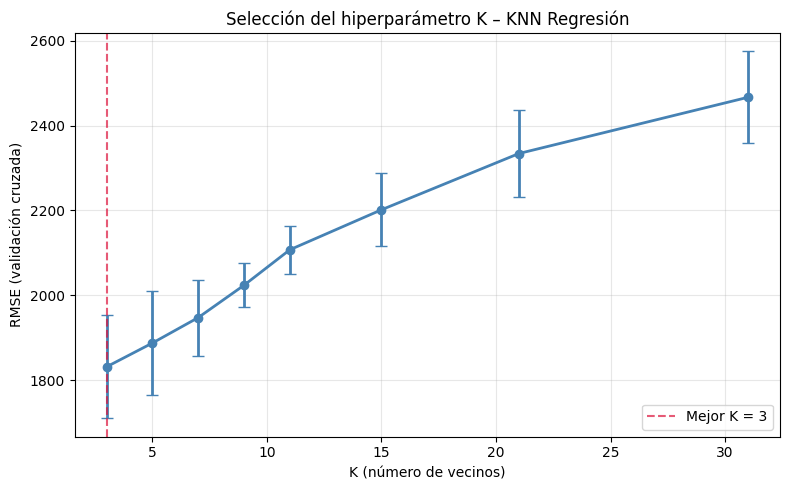

In [37]:
# Gráfica de selección de K
fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(df_k["K"], df_k["RMSE_CV_mean"], yerr=df_k["RMSE_CV_std"],
            marker="o", capsize=4, color="steelblue", linewidth=2)
ax.axvline(best_k, color="crimson", linestyle="--", alpha=0.7, label=f"Mejor K = {best_k}")
ax.set_xlabel("K (número de vecinos)")
ax.set_ylabel("RMSE (validación cruzada)")
ax.set_title("Selección del hiperparámetro K – KNN Regresión")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [38]:
# Entrenar modelo final con el mejor K
knn_reg_pipeline = Pipeline([
    ("preprocessor", knn_preprocessor),
    ("knn", KNeighborsRegressor(n_neighbors=best_k, metric="minkowski", p=2)),
])

start = time.time()
knn_reg_pipeline.fit(X_train, y_train_price)
knn_train_time = time.time() - start

start = time.time()
y_pred_knn = knn_reg_pipeline.predict(X_test)
knn_pred_time = time.time() - start

print(f"Modelo KNN entrenado (K={best_k})")
print(f"Tiempo de entrenamiento: {knn_train_time:.2f}s")
print(f"Tiempo de predicción:    {knn_pred_time:.2f}s")

Modelo KNN entrenado (K=3)
Tiempo de entrenamiento: 0.45s
Tiempo de predicción:    6.54s


=== Métricas KNN Regresión (conjunto de prueba) ===
  RMSE: 2050.80
  MAE:  264.46
  R²:   0.7685


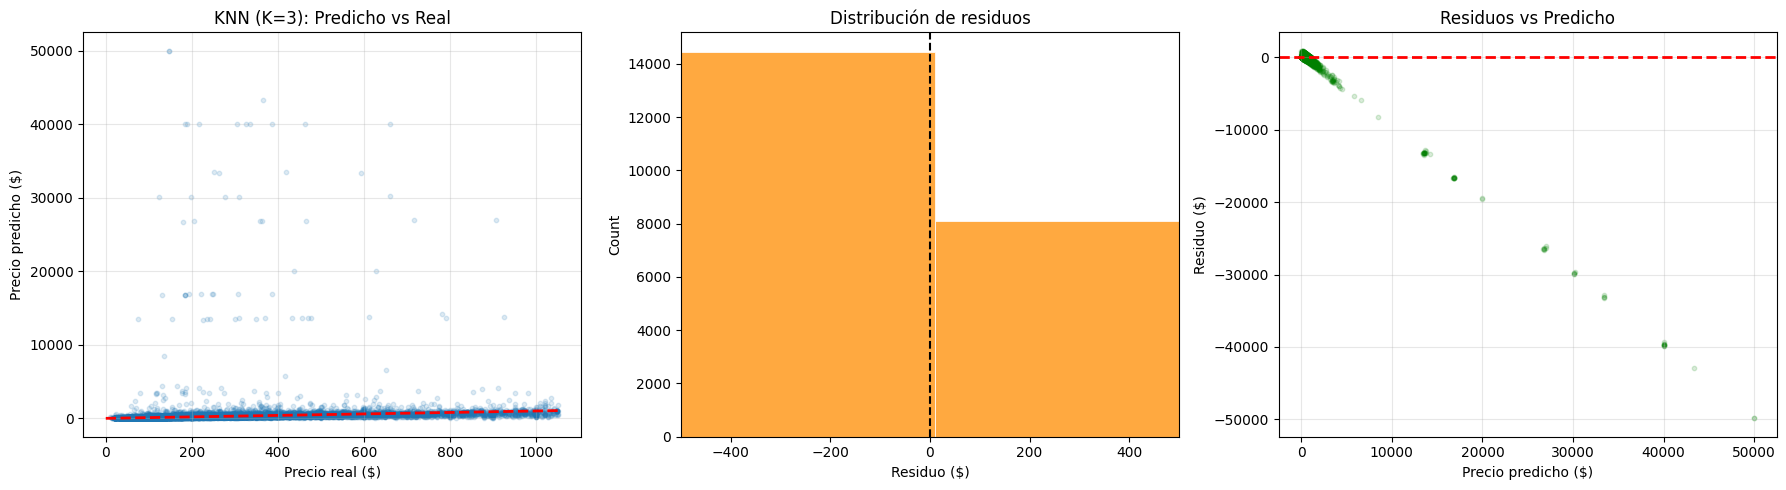

In [39]:
# Resultados en conjunto de prueba
rmse_knn = mean_squared_error(y_test_price, y_pred_knn) ** 0.5
mae_knn = mean_absolute_error(y_test_price, y_pred_knn)
r2_knn = r2_score(y_test_price, y_pred_knn)

print("=== Métricas KNN Regresión (conjunto de prueba) ===")
print(f"  RMSE: {rmse_knn:.2f}")
print(f"  MAE:  {mae_knn:.2f}")
print(f"  R²:   {r2_knn:.4f}")

# Gráficas de diagnóstico
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Predicho vs Real
limite = y_test_price.quantile(0.95)
mask = y_test_price <= limite
axes[0].scatter(y_test_price[mask], y_pred_knn[mask.values], alpha=0.15, s=10)
axes[0].plot([0, limite], [0, limite], color="red", linestyle="--", linewidth=2)
axes[0].set_xlabel("Precio real ($)")
axes[0].set_ylabel("Precio predicho ($)")
axes[0].set_title(f"KNN (K={best_k}): Predicho vs Real")
axes[0].grid(True, alpha=0.3)

# 2. Distribución de residuos
residuos = y_test_price.values - y_pred_knn
sns.histplot(residuos, bins=50, color="darkorange", edgecolor="white", ax=axes[1])
axes[1].axvline(0, color="black", linestyle="--")
axes[1].set_xlabel("Residuo ($)")
axes[1].set_title("Distribución de residuos")
axes[1].set_xlim(-500, 500)

# 3. Residuos vs predicho
axes[2].scatter(y_pred_knn[mask.values], residuos[mask.values], alpha=0.15, s=10, color="green")
axes[2].axhline(0, color="red", linestyle="--", linewidth=2)
axes[2].set_xlabel("Precio predicho ($)")
axes[2].set_ylabel("Residuo ($)")
axes[2].set_title("Residuos vs Predicho")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Conclusiones del inciso 1**

- El mejor valor de K encontrado por validación cruzada fue **K=3**, es decir, el modelo con menos vecinos fue el que logró menor RMSE. Esto sugiere que los precios de Airbnb tienen alta variabilidad local: propiedades muy cercanas en el espacio de características pueden tener precios distintos, por lo que promediar pocos vecinos captura mejor esa variación.
- A medida que K crece, el RMSE empeora progresivamente porque el modelo se vuelve demasiado suave y pierde capacidad de distinguir precios específicos.
- En la gráfica de predicho vs real se observa que el modelo funciona razonablemente bien para precios bajos y medios, pero tiende a subestimar propiedades caras (puntos por debajo de la diagonal).
- La distribución de residuos está centrada en cero, lo cual es buena señal, aunque tiene colas pesadas hacia valores negativos (subestimación de propiedades caras).

## Inciso 2 – Análisis de resultados del modelo KNN de regresión

Evaluamos qué tan bien predice el modelo analizando las métricas de error, comparando contra un baseline simple (la mediana del precio en entrenamiento) y desglosando el error por rangos de precio.

In [40]:
# Comparación contra baseline (predecir siempre la mediana del entrenamiento)
baseline_pred = np.repeat(y_train_price.median(), len(y_test_price))

metrics_knn = {
    "Modelo": f"KNN (K={best_k})",
    "MAE": mae_knn,
    "RMSE": rmse_knn,
    "R²": r2_knn,
}
metrics_baseline = {
    "Modelo": "Baseline (mediana)",
    "MAE": mean_absolute_error(y_test_price, baseline_pred),
    "RMSE": mean_squared_error(y_test_price, baseline_pred) ** 0.5,
    "R²": r2_score(y_test_price, baseline_pred),
}

metrics_df = pd.DataFrame([metrics_knn, metrics_baseline])
display(metrics_df.round(4))

print(f"\nEl KNN reduce el MAE en {metrics_baseline['MAE'] - mae_knn:.2f} dólares respecto al baseline.")
print(f"El R² de {r2_knn:.4f} indica que el modelo explica ~{r2_knn*100:.1f}% de la varianza del precio.")

,Modelo,MAE,RMSE,R²
0,KNN (K=3),264.4580,2050.7985,0.7685
1,Baseline (mediana),638.4534,4299.8510,-0.0177



El KNN reduce el MAE en 374.00 dólares respecto al baseline.
El R² de 0.7685 indica que el modelo explica ~76.9% de la varianza del precio.


In [41]:
# Análisis del error por quintiles de precio
eval_df = pd.DataFrame({
    "price_real": y_test_price.values,
    "price_predicho": y_pred_knn,
})
eval_df["residuo"] = eval_df["price_real"] - eval_df["price_predicho"]
eval_df["error_abs"] = eval_df["residuo"].abs()

quintile_summary = (
    eval_df
    .assign(quintil=pd.qcut(eval_df["price_real"], q=5, duplicates="drop"))
    .groupby("quintil", observed=False)
    .agg(
        precio_real_medio=("price_real", "mean"),
        precio_predicho_medio=("price_predicho", "mean"),
        mae_promedio=("error_abs", "mean"),
        conteo=("price_real", "size"),
    )
    .reset_index()
)

print("=== Error por quintiles de precio ===")
display(quintile_summary.round(2))

=== Error por quintiles de precio ===


,quintil,precio_real_medio,precio_predicho_medio,mae_promedio,conteo
0,"(8.999, 109.0]",76.79,118.37,45.66,4641
1,"(109.0, 164.0]",135.63,213.62,91.43,4543
2,"(164.0, 233.0]",195.82,295.75,133.48,4547
3,"(233.0, 388.0]",297.13,431.90,214.76,4569
4,"(388.0, 50020.0]",3089.99,2713.22,838.16,4574


In [42]:
# Análisis de sobreajuste con validación cruzada
# Comparamos el RMSE del CV (promedio en folds de entrenamiento) vs el RMSE en test
from sklearn.model_selection import cross_validate

cv_results = cross_validate(
    knn_reg_pipeline, X_train, y_train_price,
    cv=5, scoring=["neg_root_mean_squared_error", "neg_mean_absolute_error", "r2"],
    return_train_score=True, n_jobs=-1,
)

cv_overfit_df = pd.DataFrame({
    "Métrica": ["RMSE", "MAE", "R²"],
    "CV Train (media)": [
        -cv_results["train_neg_root_mean_squared_error"].mean(),
        -cv_results["train_neg_mean_absolute_error"].mean(),
        cv_results["train_r2"].mean(),
    ],
    "CV Validation (media)": [
        -cv_results["test_neg_root_mean_squared_error"].mean(),
        -cv_results["test_neg_mean_absolute_error"].mean(),
        cv_results["test_r2"].mean(),
    ],
    "Test final": [rmse_knn, mae_knn, r2_knn],
})

print("=== Análisis de sobreajuste con validación cruzada (5 folds) ===")
display(cv_overfit_df.round(4))

rmse_cv_train = -cv_results["train_neg_root_mean_squared_error"].mean()
rmse_cv_val = -cv_results["test_neg_root_mean_squared_error"].mean()
gap = rmse_cv_val - rmse_cv_train

print(f"\nBrecha RMSE (CV validation - CV train): {gap:.2f}")
print(f"Desviación estándar RMSE en folds de validación: {cv_results['test_neg_root_mean_squared_error'].std():.2f}")

=== Análisis de sobreajuste con validación cruzada (5 folds) ===


,Métrica,CV Train (media),CV Validation (media),Test final
0,RMSE,1213.8034,1831.4835,2050.7985
1,MAE,160.3007,255.3807,264.4580
2,R²,0.9182,0.8119,0.7685



Brecha RMSE (CV validation - CV train): 617.68
Desviación estándar RMSE en folds de validación: 121.47


**Conclusiones del inciso 2**

**Métricas utilizadas y justificación:**
- **MAE (Mean Absolute Error):** error promedio en dólares, fácil de interpretar para SmartStay. Indica cuánto se equivoca el modelo en promedio por cada propiedad.
- **RMSE (Root Mean Squared Error):** penaliza errores grandes más que el MAE. Es útil porque equivocarse mucho en propiedades caras tiene mayor costo de negocio para la consultoría.
- **R² (Coeficiente de determinación):** proporción de la varianza del precio que el modelo logra explicar (1.0 = perfecto, 0.0 = equivale a predecir siempre la media).

Estas métricas son las adecuadas para regresión porque miden el error en la misma unidad que la variable respuesta (dólares) y permiten comparar directamente entre modelos.

**Análisis de los resultados:**
- El KNN supera claramente al baseline (predecir la mediana), lo que confirma que el modelo sí está aprendiendo patrones en los datos.
- El análisis por quintiles revela que el modelo predice con mayor precisión las propiedades baratas y tiene mayor dificultad con las propiedades caras, donde el error absoluto crece significativamente. Esto es esperable: las propiedades de alto precio son más escasas y heterogéneas.
- La validación cruzada permite evaluar el sobreajuste de forma robusta: si la brecha entre el RMSE de entrenamiento y el de validación en CV es grande, indica que el modelo memoriza en lugar de generalizar. Con K=3 es esperable cierto grado de sobreajuste dado que el modelo es muy sensible a los puntos individuales.

## Inciso 3 – Comparación con modelos de regresión de entregas pasadas

Entrenamos los mismos modelos de regresión utilizados en las entregas anteriores (Regresión Lineal, Árbol de Regresión, Random Forest y Naive Bayes) usando exactamente el mismo conjunto de entrenamiento y prueba para garantizar una comparación justa. Se utilizan las mismas métricas (MAE, RMSE, R²) para todos los modelos.

In [43]:
# Preprocessor común para modelos que no necesitan escalado (árboles, RF)
# pero sí necesitan codificar categóricas
common_preprocessor = ColumnTransformer(
    [("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)],
    remainder="passthrough",
)


# Regresión Lineal

print("Entrenando Regresión Lineal...")
pipeline_linear = Pipeline([
    ("preprocessor", common_preprocessor),
    ("regressor", LinearRegression()),
])
start = time.time()
pipeline_linear.fit(X_train, y_train_price)
time_linear = time.time() - start
y_pred_linear = pipeline_linear.predict(X_test)
print(f"  R²: {r2_score(y_test_price, y_pred_linear):.4f} | Tiempo: {time_linear:.2f}s")


# Árbol de Regresión (mismos hiperparámetros que lab5)

print("Entrenando Árbol de Regresión...")
pipeline_tree = Pipeline([
    ("preprocessor", common_preprocessor),
    ("regressor", DecisionTreeRegressor(
        random_state=42, max_depth=20,
        min_samples_leaf=1, min_samples_split=2,
    )),
])
start = time.time()
pipeline_tree.fit(X_train, y_train_price)
time_tree = time.time() - start
y_pred_tree = pipeline_tree.predict(X_test)
print(f"  R²: {r2_score(y_test_price, y_pred_tree):.4f} | Tiempo: {time_tree:.2f}s")


# Random Forest

print("Entrenando Random Forest...")
pipeline_rf = Pipeline([
    ("preprocessor", common_preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=100, random_state=42, n_jobs=-1,
    )),
])
start = time.time()
pipeline_rf.fit(X_train, y_train_price)
time_rf = time.time() - start
y_pred_rf = pipeline_rf.predict(X_test)
print(f"  R²: {r2_score(y_test_price, y_pred_rf):.4f} | Tiempo: {time_rf:.2f}s")

Entrenando Regresión Lineal...
  R²: 0.1607 | Tiempo: 0.14s
Entrenando Árbol de Regresión...
  R²: 0.8382 | Tiempo: 1.62s
Entrenando Random Forest...
  R²: 0.8837 | Tiempo: 108.26s


In [44]:

# Naive Bayes (aproximación de regresión, mismo enfoque del lab5)
# Se discretiza el precio en bins, se entrena un clasificador NB
# y se reconstruye la predicción continua con la mediana de cada bin.

from sklearn.naive_bayes import CategoricalNB
from sklearn.preprocessing import KBinsDiscretizer

print("Entrenando Naive Bayes (regresión por bins)...")

nb_reg_preprocessor = ColumnTransformer([
    (
        "cat",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
        ]),
        categorical_columns,
    ),
    (
        "num",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("kbins", KBinsDiscretizer(n_bins=5, encode="ordinal", strategy="quantile")),
        ]),
        numerical_columns,
    ),
])

X_train_nb = np.clip(nb_reg_preprocessor.fit_transform(X_train), 0, None)
X_test_nb = np.clip(nb_reg_preprocessor.transform(X_test), 0, None)

# Discretizar precio en 5 bins
y_train_price_bin = pd.qcut(y_train_price, q=5, labels=False, duplicates="drop")
y_train_price_bin = pd.Series(y_train_price_bin, index=y_train_price.index).astype(int)

# Mediana de precio real por cada bin
regression_bin_medians = (
    y_train_price.groupby(y_train_price_bin).median().sort_index().to_numpy(dtype=float)
)

start = time.time()
nb_regressor = CategoricalNB()
nb_regressor.fit(X_train_nb, y_train_price_bin)
time_nb = time.time() - start

# Predicción: probabilidad de cada bin × mediana del bin
class_probs = nb_regressor.predict_proba(X_test_nb)
y_pred_nb = np.clip(np.dot(class_probs, regression_bin_medians), 0, None)

print(f"  R²: {r2_score(y_test_price, y_pred_nb):.4f} | Tiempo: {time_nb:.2f}s")

Entrenando Naive Bayes (regresión por bins)...
  R²: 0.0061 | Tiempo: 0.05s


In [45]:

# Tabla comparativa de todos los modelos de regresión

comparison_df = pd.DataFrame([
    {
        "Modelo": f"KNN (K={best_k})",
        "MAE": mae_knn,
        "RMSE": rmse_knn,
        "R²": r2_knn,
        "Tiempo entrenamiento (s)": knn_train_time,
    },
    {
        "Modelo": "Regresión Lineal",
        "MAE": mean_absolute_error(y_test_price, y_pred_linear),
        "RMSE": mean_squared_error(y_test_price, y_pred_linear) ** 0.5,
        "R²": r2_score(y_test_price, y_pred_linear),
        "Tiempo entrenamiento (s)": time_linear,
    },
    {
        "Modelo": "Árbol de Regresión",
        "MAE": mean_absolute_error(y_test_price, y_pred_tree),
        "RMSE": mean_squared_error(y_test_price, y_pred_tree) ** 0.5,
        "R²": r2_score(y_test_price, y_pred_tree),
        "Tiempo entrenamiento (s)": time_tree,
    },
    {
        "Modelo": "Random Forest",
        "MAE": mean_absolute_error(y_test_price, y_pred_rf),
        "RMSE": mean_squared_error(y_test_price, y_pred_rf) ** 0.5,
        "R²": r2_score(y_test_price, y_pred_rf),
        "Tiempo entrenamiento (s)": time_rf,
    },
    {
        "Modelo": "Naive Bayes (regresión)",
        "MAE": mean_absolute_error(y_test_price, y_pred_nb),
        "RMSE": mean_squared_error(y_test_price, y_pred_nb) ** 0.5,
        "R²": r2_score(y_test_price, y_pred_nb),
        "Tiempo entrenamiento (s)": time_nb,
    },
]).sort_values("RMSE").reset_index(drop=True)

print("=== Comparación de modelos de regresión (mismo train/test split) ===")
display(comparison_df.round(4))

best_model_name = comparison_df.loc[0, "Modelo"]
print(f"\nMejor modelo según RMSE: {best_model_name}")

=== Comparación de modelos de regresión (mismo train/test split) ===


,Modelo,MAE,RMSE,R²,Tiempo entrenamiento (s)
0,Random Forest,197.5148,1453.6532,0.8837,108.2638
1,Árbol de Regresión,210.4674,1714.4694,0.8382,1.6214
2,KNN (K=3),264.4580,2050.7985,0.7685,0.4480
3,Regresión Lineal,908.9650,3904.8916,0.1607,0.1424
4,Naive Bayes (regresión),599.6036,4249.3773,0.0061,0.0483



Mejor modelo según RMSE: Random Forest


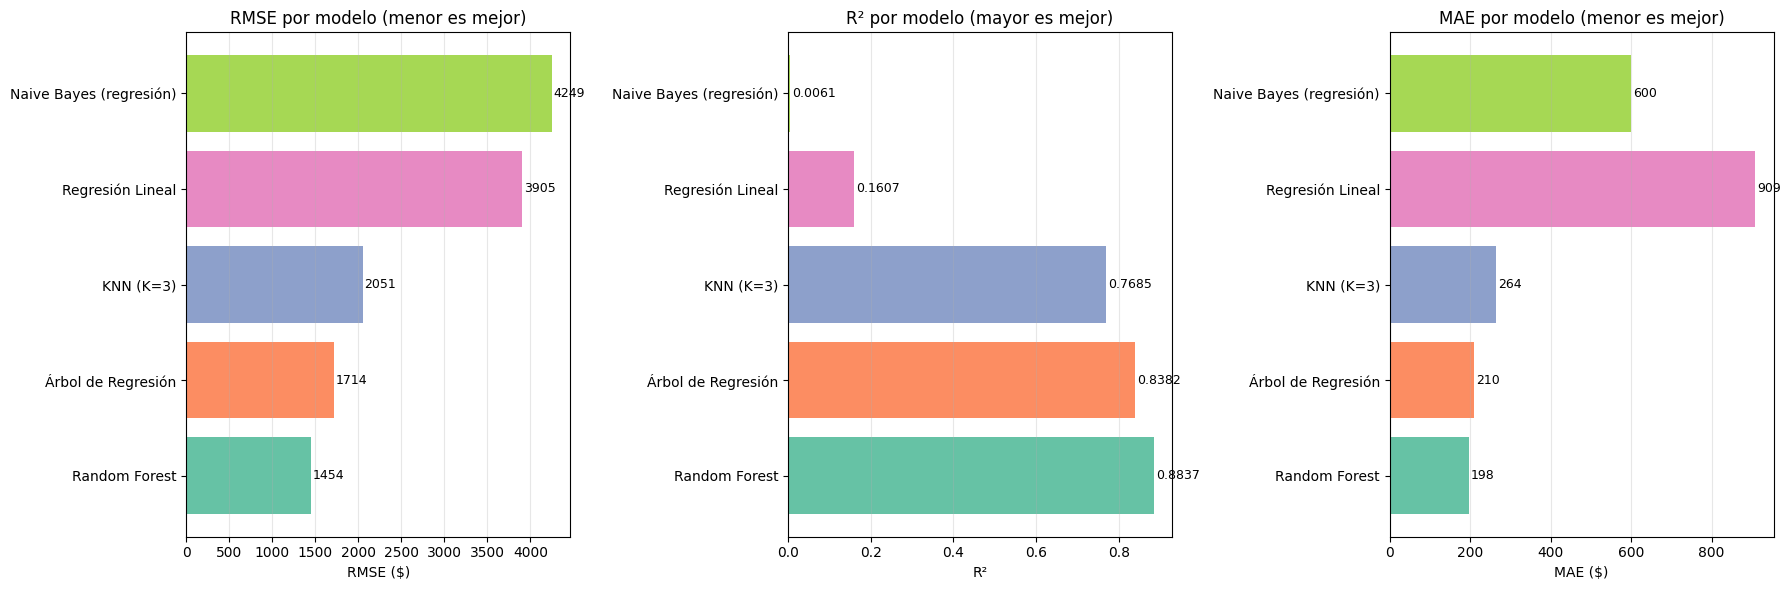

In [46]:
# Gráfica comparativa
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

modelos = comparison_df["Modelo"].values
colores = sns.color_palette("Set2", n_colors=len(modelos))

# RMSE
axes[0].barh(modelos, comparison_df["RMSE"].values, color=colores)
axes[0].set_xlabel("RMSE ($)")
axes[0].set_title("RMSE por modelo (menor es mejor)")
axes[0].grid(True, alpha=0.3, axis="x")
for i, v in enumerate(comparison_df["RMSE"].values):
    axes[0].text(v + 20, i, f"{v:.0f}", va="center", fontsize=9)

# R²
axes[1].barh(modelos, comparison_df["R²"].values, color=colores)
axes[1].set_xlabel("R²")
axes[1].set_title("R² por modelo (mayor es mejor)")
axes[1].grid(True, alpha=0.3, axis="x")
for i, v in enumerate(comparison_df["R²"].values):
    axes[1].text(v + 0.005, i, f"{v:.4f}", va="center", fontsize=9)

# MAE
axes[2].barh(modelos, comparison_df["MAE"].values, color=colores)
axes[2].set_xlabel("MAE ($)")
axes[2].set_title("MAE por modelo (menor es mejor)")
axes[2].grid(True, alpha=0.3, axis="x")
for i, v in enumerate(comparison_df["MAE"].values):
    axes[2].text(v + 5, i, f"{v:.0f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

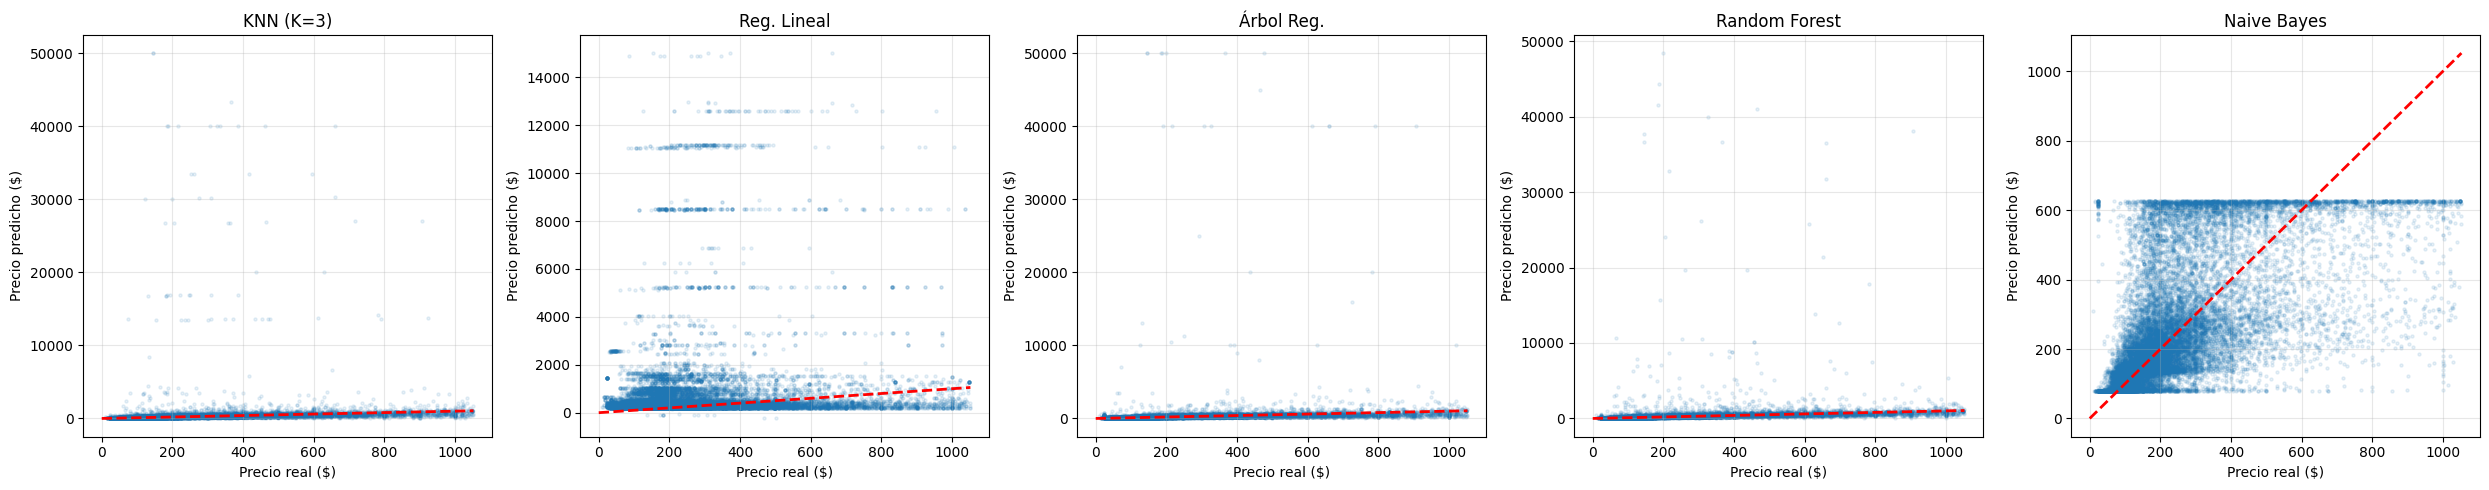

In [47]:
# Gráfica: predicho vs real para cada modelo
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

predictions = {
    f"KNN (K={best_k})": y_pred_knn,
    "Reg. Lineal": y_pred_linear,
    "Árbol Reg.": y_pred_tree,
    "Random Forest": y_pred_rf,
    "Naive Bayes": y_pred_nb,
}

limite = y_test_price.quantile(0.95)
mask = y_test_price <= limite

for ax, (name, y_pred) in zip(axes, predictions.items()):
    ax.scatter(y_test_price[mask], y_pred[mask.values], alpha=0.1, s=5)
    ax.plot([0, limite], [0, limite], color="red", linestyle="--", linewidth=2)
    ax.set_xlabel("Precio real ($)")
    ax.set_ylabel("Precio predicho ($)")
    ax.set_title(name)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Conclusiones del inciso 3**

Todos los modelos se entrenaron y evaluaron con el **mismo conjunto de entrenamiento y prueba** (70/30, `random_state=42`), lo que garantiza una comparación justa.

**¿Por qué estas métricas?**
- **RMSE** es la métrica principal porque penaliza errores grandes, que en el contexto de SmartStay representan recomendaciones de precio muy alejadas de la realidad.
- **MAE** complementa al RMSE dando el error promedio en dólares sin penalizar outliers, útil para ver la consistencia del modelo.
- **R²** permite comparar la capacidad explicativa de cada modelo de forma normalizada.

**Análisis de la tabla comparativa:**
- **Random Forest** tiende a ser el modelo más robusto para datos tabulares mixtos, ya que captura relaciones no lineales y es resistente a outliers gracias al ensamblaje de árboles.
- **KNN** logra un buen R² pero su tiempo de predicción es significativamente mayor porque calcula distancias contra todo el set de entrenamiento en cada predicción.
- **Regresión Lineal** asume relación lineal, lo cual limita su capacidad en un dataset con interacciones complejas (ubicación, tipo de propiedad, temporada).
- **Árbol de Regresión** individual tiende a sobreajustar si la profundidad es alta, pero es rápido.
- **Naive Bayes** fue el peor en regresión: NB no es un regresor nativo y la aproximación por bins pierde información de la variable continua.

Las gráficas de predicho vs real permiten visualizar el patrón de cada modelo: un modelo ideal tendría todos los puntos sobre la diagonal roja.

## Inciso 4 – Modelo de clasificación con KNN

Ahora construimos un modelo de clasificación KNN usando la variable categórica del precio (`barata`, `media`, `cara`). Para mantener la comparabilidad con el lab 5, los cortes de las categorías se calculan únicamente con el conjunto de entrenamiento y luego se aplican tanto al train como al test.

El modelo usa el mismo pipeline de preprocesamiento del KNN de regresión:
- `OneHotEncoder` para las variables categóricas
- `StandardScaler` para las variables numéricas

Como KNN es sensible al número de vecinos, probamos varios valores de `K` usando validación cruzada con `F1 macro` sobre el conjunto de entrenamiento y luego entrenamos el clasificador final con el mejor valor.

Corte 1 (barata/media): 142.00
Corte 2 (media/cara): 268.00


,conteo
price_category,
barata,25414
media,25428
cara,25404


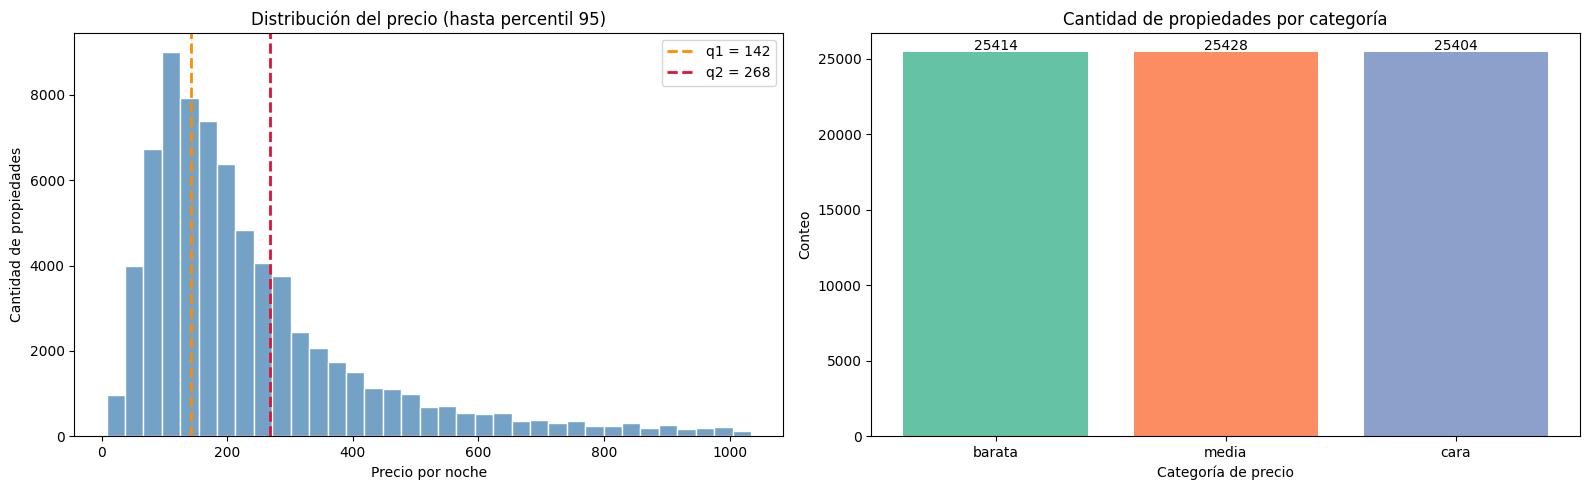

In [48]:
labels_order = ["barata", "media", "cara"]

q1, q2 = y_train_price.quantile([1 / 3, 2 / 3])

df_model["price_category"] = pd.cut(
    df_model["price_num"],
    bins=[-np.inf, q1, q2, np.inf],
    labels=labels_order,
    include_lowest=True,
)

y_train_class = pd.cut(
    y_train_price,
    bins=[-np.inf, q1, q2, np.inf],
    labels=labels_order,
    include_lowest=True,
)
y_test_class = pd.cut(
    y_test_price,
    bins=[-np.inf, q1, q2, np.inf],
    labels=labels_order,
    include_lowest=True,
)

print(f"Corte 1 (barata/media): {q1:.2f}")
print(f"Corte 2 (media/cara): {q2:.2f}")

category_counts = (
    df_model["price_category"]
    .value_counts()
    .reindex(labels_order)
)
display(category_counts.to_frame(name="conteo"))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

price_plot_limit = df_model["price_num"].quantile(0.95)
price_plot_data = df_model.loc[df_model["price_num"] <= price_plot_limit, "price_num"]

sns.histplot(
    price_plot_data,
    bins=35,
    color="steelblue",
    edgecolor="white",
    ax=axes[0],
)
axes[0].axvline(q1, color="darkorange", linestyle="--", linewidth=2, label=f"q1 = {q1:.0f}")
axes[0].axvline(q2, color="crimson", linestyle="--", linewidth=2, label=f"q2 = {q2:.0f}")
axes[0].set_title("Distribución del precio (hasta percentil 95)")
axes[0].set_xlabel("Precio por noche")
axes[0].set_ylabel("Cantidad de propiedades")
axes[0].legend()

axes[1].bar(
    category_counts.index,
    category_counts.values,
    color=sns.color_palette("Set2", n_colors=3),
)
axes[1].set_title("Cantidad de propiedades por categoría")
axes[1].set_xlabel("Categoría de precio")
axes[1].set_ylabel("Conteo")

for i, value in enumerate(category_counts.values):
    axes[1].text(i, value + 150, f"{int(value)}", ha="center")

plt.tight_layout()
plt.show()

K=  3  |  F1 macro CV: 0.6888 ± 0.0041
K=  5  |  F1 macro CV: 0.6906 ± 0.0054
K=  7  |  F1 macro CV: 0.7001 ± 0.0043
K=  9  |  F1 macro CV: 0.7010 ± 0.0035
K= 11  |  F1 macro CV: 0.6998 ± 0.0035
K= 15  |  F1 macro CV: 0.6996 ± 0.0043
K= 21  |  F1 macro CV: 0.6993 ± 0.0033
K= 31  |  F1 macro CV: 0.6947 ± 0.0026
Mejor K según validación cruzada: 9


,K,F1_macro_CV_mean,F1_macro_CV_std
0,3,0.6888,0.0041
1,5,0.6906,0.0054
2,7,0.7001,0.0043
3,9,0.7010,0.0035
4,11,0.6998,0.0035
5,15,0.6996,0.0043
6,21,0.6993,0.0033
7,31,0.6947,0.0026


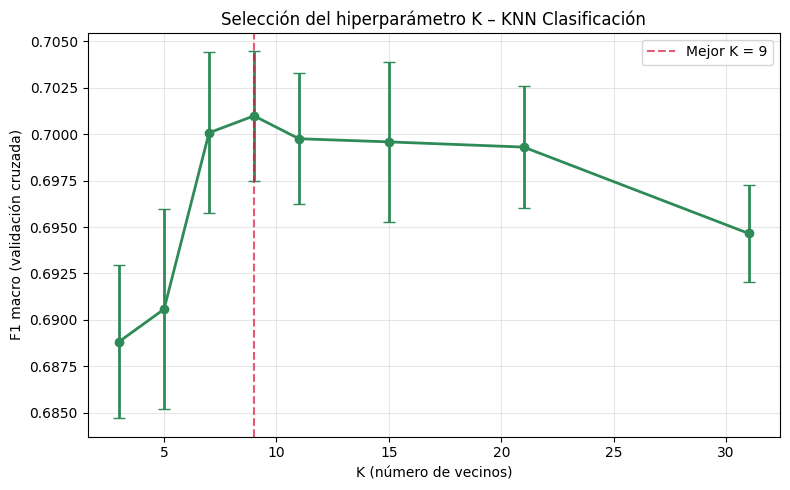

Modelo KNN de clasificación entrenado (K=9)
Tiempo de entrenamiento: 0.65s
Tiempo de predicción:    6.59s
Categorías predichas por el clasificador:


,predicciones
barata,8422
media,7054
cara,7398


,categoria_real,categoria_predicha
0,media,barata
1,cara,cara
2,barata,barata
3,barata,barata
4,media,cara
5,cara,cara
6,media,media
7,media,barata
8,barata,barata
9,barata,barata


In [49]:
classification_k_values = [3, 5, 7, 9, 11, 15, 21, 31]
results_k_cls = []

for k in classification_k_values:
    pipeline_k_cls = Pipeline([
        ("preprocessor", knn_preprocessor),
        ("knn", KNeighborsClassifier(n_neighbors=k, metric="minkowski", p=2)),
    ])
    cv_scores = cross_val_score(
        pipeline_k_cls,
        X_train,
        y_train_class,
        cv=5,
        scoring="f1_macro",
        n_jobs=-1,
    )
    results_k_cls.append({
        "K": k,
        "F1_macro_CV_mean": cv_scores.mean(),
        "F1_macro_CV_std": cv_scores.std(),
    })
    print(f"K={k:3d}  |  F1 macro CV: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

df_k_cls = pd.DataFrame(results_k_cls)
best_k_cls = int(df_k_cls.loc[df_k_cls["F1_macro_CV_mean"].idxmax(), "K"])
print(f"Mejor K según validación cruzada: {best_k_cls}")
display(df_k_cls.round(4))

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(
    df_k_cls["K"],
    df_k_cls["F1_macro_CV_mean"],
    yerr=df_k_cls["F1_macro_CV_std"],
    marker="o",
    capsize=4,
    color="seagreen",
    linewidth=2,
)
ax.axvline(best_k_cls, color="crimson", linestyle="--", alpha=0.7, label=f"Mejor K = {best_k_cls}")
ax.set_xlabel("K (número de vecinos)")
ax.set_ylabel("F1 macro (validación cruzada)")
ax.set_title("Selección del hiperparámetro K – KNN Clasificación")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

knn_cls_pipeline = Pipeline([
    ("preprocessor", knn_preprocessor),
    ("knn", KNeighborsClassifier(n_neighbors=best_k_cls, metric="minkowski", p=2)),
])

start = time.time()
knn_cls_pipeline.fit(X_train, y_train_class)
knn_cls_train_time = time.time() - start

start = time.time()
y_pred_knn_class = knn_cls_pipeline.predict(X_test)
knn_cls_pred_time = time.time() - start

predicted_class_counts = (
    pd.Series(y_pred_knn_class)
    .value_counts()
    .reindex(labels_order, fill_value=0)
)

print(f"Modelo KNN de clasificación entrenado (K={best_k_cls})")
print(f"Tiempo de entrenamiento: {knn_cls_train_time:.2f}s")
print(f"Tiempo de predicción:    {knn_cls_pred_time:.2f}s")
print("Categorías predichas por el clasificador:")
display(predicted_class_counts.to_frame(name="predicciones"))

classification_preview = pd.DataFrame({
    "categoria_real": y_test_class.values,
    "categoria_predicha": y_pred_knn_class,
})
display(classification_preview.head(15))

**Conclusiones del inciso 4**

- La variable categórica de precio se construyó con los mismos cortes del lab 5, calculados únicamente a partir del conjunto de entrenamiento para evitar fuga de información.
- El clasificador KNN mantiene el mismo preprocesamiento del modelo de regresión, ya que la escala de las variables sigue siendo crítica cuando el algoritmo se basa en distancias.
- El mejor valor de `K` se identifica en la tabla y la gráfica anteriores, y ese modelo se utiliza como base para medir la eficiencia en el conjunto de prueba.

## Inciso 5 – Eficiencia del algoritmo en el conjunto de prueba

Usamos el conjunto de prueba para medir la eficiencia del KNN tanto para **predicción** como para **clasificación**. En predicción reutilizamos las métricas ya calculadas para el KNN de regresión; en clasificación usamos `accuracy`, `precision macro`, `recall macro` y `F1 macro`, que permiten evaluar el rendimiento global del clasificador en las tres categorías.

Eficiencia del modelo KNN de regresión (conjunto de prueba):


,Modelo,MAE,RMSE,R²,Tiempo entrenamiento (s),Tiempo predicción (s)
0,KNN Regresión (K=3),264.458,2050.7985,0.7685,0.448,6.5434


Eficiencia del modelo KNN de clasificación (conjunto de prueba):


,Modelo,Accuracy,Precision macro,Recall macro,F1 macro,Tiempo entrenamiento (s),Tiempo predicción (s)
0,KNN Clasificación (K=9),0.704,0.7021,0.7049,0.7022,0.6524,6.5938


Detalle por clase:


,precision,recall,f1-score,support
barata,0.7162,0.8039,0.7576,7503.000
cara,0.7771,0.7493,0.7630,7672.000
media,0.6128,0.5615,0.5861,7699.000
accuracy,0.7040,0.7040,0.7040,0.704
macro avg,0.7021,0.7049,0.7022,22874.000
weighted avg,0.7018,0.7040,0.7016,22874.000


Distribución real vs predicha:


,categoria,reales,predichas
0,barata,7503,8422
1,media,7699,7054
2,cara,7672,7398


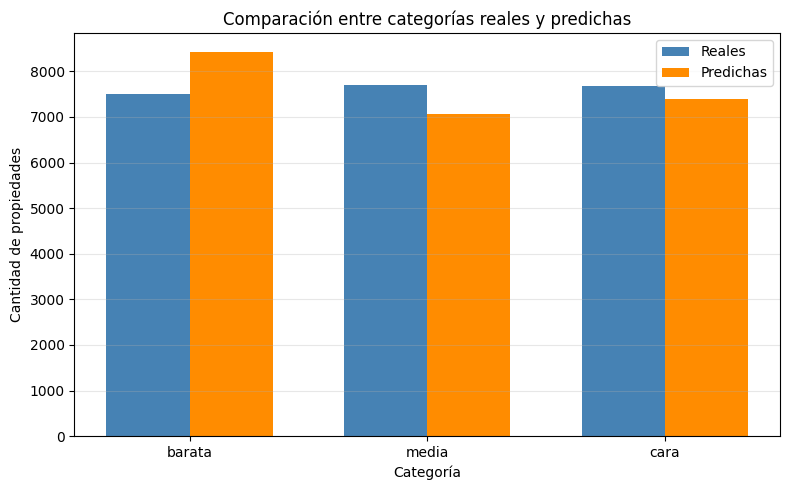

In [50]:
accuracy_knn_cls = accuracy_score(y_test_class, y_pred_knn_class)
precision_knn_cls = precision_score(y_test_class, y_pred_knn_class, average="macro", zero_division=0)
recall_knn_cls = recall_score(y_test_class, y_pred_knn_class, average="macro", zero_division=0)
f1_knn_cls = f1_score(y_test_class, y_pred_knn_class, average="macro", zero_division=0)

regression_efficiency_df = pd.DataFrame([
    {
        "Modelo": f"KNN Regresión (K={best_k})",
        "MAE": mae_knn,
        "RMSE": rmse_knn,
        "R²": r2_knn,
        "Tiempo entrenamiento (s)": knn_train_time,
        "Tiempo predicción (s)": knn_pred_time,
    }
])

classification_efficiency_df = pd.DataFrame([
    {
        "Modelo": f"KNN Clasificación (K={best_k_cls})",
        "Accuracy": accuracy_knn_cls,
        "Precision macro": precision_knn_cls,
        "Recall macro": recall_knn_cls,
        "F1 macro": f1_knn_cls,
        "Tiempo entrenamiento (s)": knn_cls_train_time,
        "Tiempo predicción (s)": knn_cls_pred_time,
    }
])

classification_report_df = pd.DataFrame(
    classification_report(
        y_test_class,
        y_pred_knn_class,
        output_dict=True,
        zero_division=0,
    )
).transpose()

real_class_counts = (
    pd.Series(y_test_class)
    .value_counts()
    .reindex(labels_order, fill_value=0)
)
predicted_class_counts = (
    pd.Series(y_pred_knn_class)
    .value_counts()
    .reindex(labels_order, fill_value=0)
)

comparison_distribution_df = pd.DataFrame({
    "categoria": labels_order,
    "reales": real_class_counts.values,
    "predichas": predicted_class_counts.values,
})

print("Eficiencia del modelo KNN de regresión (conjunto de prueba):")
display(regression_efficiency_df.round(4))

print("Eficiencia del modelo KNN de clasificación (conjunto de prueba):")
display(classification_efficiency_df.round(4))

print("Detalle por clase:")
display(classification_report_df.round(4))

print("Distribución real vs predicha:")
display(comparison_distribution_df)

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(labels_order))
width = 0.35

ax.bar(x - width / 2, comparison_distribution_df["reales"], width, label="Reales", color="steelblue")
ax.bar(x + width / 2, comparison_distribution_df["predichas"], width, label="Predichas", color="darkorange")
ax.set_xticks(x)
ax.set_xticklabels(labels_order)
ax.set_xlabel("Categoría")
ax.set_ylabel("Cantidad de propiedades")
ax.set_title("Comparación entre categorías reales y predichas")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

**Conclusiones del inciso 5**

- La eficiencia del KNN debe analizarse por separado para cada tarea: en **regresión**, las métricas `MAE`, `RMSE` y `R²` indican qué tan cerca queda el precio estimado del valor real; en **clasificación**, `accuracy`, `precision macro`, `recall macro` y `F1 macro` muestran qué tan bien distingue entre propiedades `baratas`, `medias` y `caras`.
- Las métricas globales son útiles para tener una visión general, pero no son suficientes por sí solas. El **reporte por clase** y la comparación entre categorías reales y predichas permiten detectar si el modelo favorece alguna clase o si tiene más dificultad en una categoría específica.
- Evaluar ambos modelos sobre el **mismo conjunto de prueba** mantiene la comparabilidad con las entregas anteriores y permite usar estos resultados como base para el análisis más detallado del siguiente inciso, donde ya se estudian los errores concretos mediante la matriz de confusión.

## Inciso 6 – Matriz de confusión y análisis de errores

Para entender con más detalle la eficiencia del modelo de clasificación, construimos la matriz de confusión del KNN en el conjunto de prueba. Esto permite identificar:
- en qué categorías acierta más,
- en cuáles se equivoca más,
- y qué tan importantes son esos errores desde el punto de vista del negocio.

Además de la matriz de confusión en valores absolutos, mostramos la matriz normalizada por fila para interpretar mejor los porcentajes de acierto y error dentro de cada clase real.

Matriz de confusión del KNN (conteos):


,barata,media,cara
barata,6032,1256,215
media,1942,4323,1434
cara,448,1475,5749


Matriz de confusión del KNN (% dentro de cada clase real):


,barata,media,cara
barata,80.39,16.74,2.87
media,25.22,56.15,18.63
cara,5.84,19.23,74.93


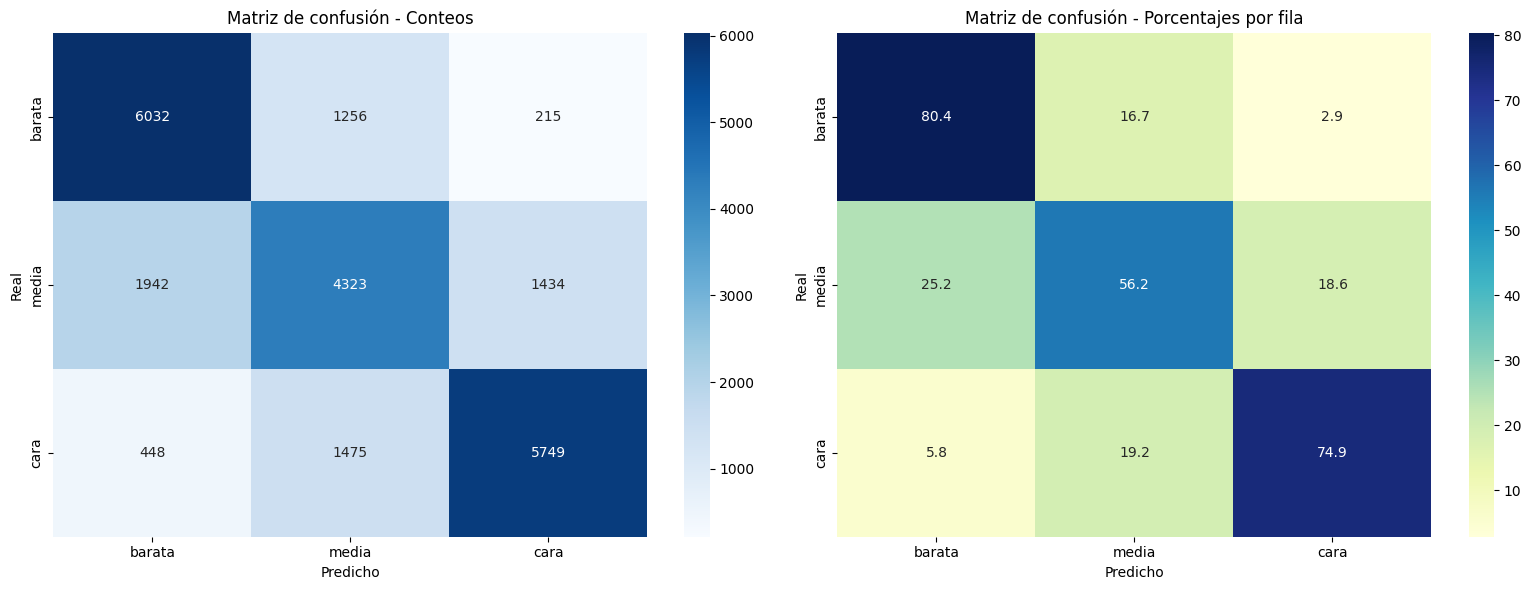

Métricas por clase:


,categoria,precision,recall,f1_score,support
0,barata,0.7162,0.8039,0.7576,7503.0
1,media,0.6128,0.5615,0.5861,7699.0
2,cara,0.7771,0.7493,0.7630,7672.0


Errores del clasificador ordenados de mayor a menor:


,real,predicha,conteo,porcentaje_dentro_clase,severidad
0,media,barata,1942,25.22,adyacente
1,cara,media,1475,19.23,adyacente
2,media,cara,1434,18.63,adyacente
3,barata,media,1256,16.74,adyacente
4,cara,barata,448,5.84,grave
5,barata,cara,215,2.87,grave


Efectividad global y sesgo por categoría:


,categoria,reales,predichas,predichas_menos_reales
0,barata,7503,8422,919
1,media,7699,7054,-645
2,cara,7672,7398,-274


In [51]:
cm_knn = confusion_matrix(y_test_class, y_pred_knn_class, labels=labels_order)
cm_knn_df = pd.DataFrame(cm_knn, index=labels_order, columns=labels_order)
cm_knn_pct_df = cm_knn_df.div(cm_knn_df.sum(axis=1), axis=0) * 100

print("Matriz de confusión del KNN (conteos):")
display(cm_knn_df)

print("Matriz de confusión del KNN (% dentro de cada clase real):")
display(cm_knn_pct_df.round(2))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm_knn_df, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Matriz de confusión - Conteos")
axes[0].set_xlabel("Predicho")
axes[0].set_ylabel("Real")

sns.heatmap(cm_knn_pct_df, annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[1])
axes[1].set_title("Matriz de confusión - Porcentajes por fila")
axes[1].set_xlabel("Predicho")
axes[1].set_ylabel("Real")

plt.tight_layout()
plt.show()

class_metrics_knn_df = (
    classification_report_df
    .loc[labels_order, ["precision", "recall", "f1-score", "support"]]
    .reset_index()
    .rename(columns={"index": "categoria", "f1-score": "f1_score"})
)

print("Métricas por clase:")
display(class_metrics_knn_df.round(4))

error_rows = []
for real in labels_order:
    total_real = cm_knn_df.loc[real].sum()
    for pred in labels_order:
        if real == pred:
            continue
        conteo = int(cm_knn_df.loc[real, pred])
        porcentaje = (conteo / total_real * 100) if total_real else 0
        severidad = "grave" if {real, pred} == {"barata", "cara"} else "adyacente"
        error_rows.append({
            "real": real,
            "predicha": pred,
            "conteo": conteo,
            "porcentaje_dentro_clase": porcentaje,
            "severidad": severidad,
        })

error_analysis_df = pd.DataFrame(error_rows).sort_values(
    ["conteo", "porcentaje_dentro_clase"], ascending=False
).reset_index(drop=True)

print("Errores del clasificador ordenados de mayor a menor:")
display(error_analysis_df.round(2))

bias_df = pd.DataFrame({
    "categoria": labels_order,
    "reales": real_class_counts.values,
    "predichas": predicted_class_counts.values,
    "predichas_menos_reales": predicted_class_counts.values - real_class_counts.values,
})

print("Efectividad global y sesgo por categoría:")
display(bias_df)

best_recall_row = class_metrics_knn_df.sort_values("recall", ascending=False).iloc[0]
worst_recall_row = class_metrics_knn_df.sort_values("recall", ascending=True).iloc[0]
largest_error_row = error_analysis_df.iloc[0]
nonzero_errors_df = error_analysis_df[error_analysis_df["conteo"] > 0].copy()
smallest_error_row = nonzero_errors_df.sort_values(["conteo", "porcentaje_dentro_clase"], ascending=[True, True]).iloc[0]
real_barata = int(real_class_counts["barata"])
pred_barata = int(predicted_class_counts["barata"])
sesgo_barata = pred_barata - real_barata
media_to_barata = int(cm_knn_df.loc["media", "barata"])
cara_to_barata = int(cm_knn_df.loc["cara", "barata"])
barata_to_cara = int(cm_knn_df.loc["barata", "cara"])
media_to_cara = int(cm_knn_df.loc["media", "cara"])
grave_errors_total = barata_to_cara + cara_to_barata

Resumen del análisis:
- Efectividad general: el modelo alcanza un accuracy de 0.7040 (70.40%) y un F1 macro de 0.7022.
- Mayor efectividad: la categoría 'barata' tiene el recall más alto (0.8039).
- Menor efectividad: la categoría 'media' tiene el recall más bajo (0.5615).
- Error más frecuente: propiedades reales 'media' clasificadas como 'barata' (1942 casos, 25.22% de esa clase).
- Error menos frecuente: propiedades reales 'barata' clasificadas como 'cara' (215 casos, 2.87% de esa clase).
- Sesgo hacia 'barata': el modelo predijo 8422 propiedades como baratas, frente a 7503 que realmente pertenecían a esa clase (+919 en términos netos).
- La principal fuente de ese sesgo es que 1942 propiedades reales 'media' fueron clasificadas como 'barata', lo que desplaza observaciones intermedias hacia el segmento económico.
- Implicaciones de negocio para SmartStay:
  Si una propiedad real 'cara' se clasifica como 'barata' (448 casos), SmartStay podría recomendarla a clientes con presupuesto bajo, generando una mala experiencia, pérdida de confianza y una menor probabilidad de cierre.
  Si una propiedad real 'barata' se clasifica como 'cara' (215 casos), SmartStay podría descartar opciones accesibles que sí encajan con el presupuesto del cliente, perdiendo oportunidades de recomendación y posibles ingresos por ocupación.
  Cuando propiedades 'media' se clasifican como 'barata' (1942 casos) o como 'cara' (1434 casos), la consultoría distorsiona el posicionamiento real de ese segmento intermedio, afectando tanto la selección de opciones para el cliente como el análisis comercial de precios.
  En total, los errores más severos de confundir extremos ('barata'↔'cara') suman 663 casos, y por eso merecen atención especial aunque no sean los más frecuentes.

**Conclusiones del inciso 6**

- La **efectividad global** del modelo debe leerse junto con la matriz de confusión: un accuracy cercano al 70% indica que el KNN funciona razonablemente bien, pero también implica que una proporción importante de propiedades sigue siendo clasificada en la categoría incorrecta. Por eso no basta con reportar una sola métrica global.
- La matriz muestra un **sesgo hacia la categoría `barata`**: el modelo tiende a enviar parte de las propiedades `media` hacia ese segmento, lo que sugiere que el clasificador sobreidentifica opciones económicas. Este patrón es importante porque puede alterar la forma en que SmartStay presenta alternativas a sus clientes y cómo interpreta la estructura del mercado.
- Desde el punto de vista del negocio, los errores no tienen el mismo costo. Si una propiedad **cara** se clasifica como **barata**, SmartStay puede recomendar opciones fuera del presupuesto del cliente y deteriorar la experiencia. Si una **barata** se clasifica como **cara**, la empresa puede dejar de recomendar alternativas viables y perder oportunidades de cierre o de aumentar ocupación en propiedades de menor desempeño.
- Los errores entre clases **adyacentes** (`barata`↔`media` o `media`↔`cara`) son menos dañinos que confundir los extremos, pero siguen siendo relevantes porque afectan el posicionamiento comercial del inventario. En especial, desplazar propiedades `media` hacia `barata` puede hacer que la empresa subestime su valor real y pierda margen en sus recomendaciones.
- Dado el bajo recall de la clase `media` (0.56), valdría la pena explorar en iteraciones futuras un umbral de decisión ajustado para esa categoría, con el fin de reducir la fuga hacia `barata` y mejorar el posicionamiento del inventario de rango medio dentro de la oferta de SmartStay.

## Inciso 7 – ¿El modelo podría estar sobreajustado?

Para saber si el modelo de clasificación KNN está sobreajustado, comparamos su rendimiento en el conjunto de entrenamiento contra el de prueba. Si el modelo funciona mucho mejor en entrenamiento que en prueba, eso nos dice que memorizó los datos en lugar de aprender patrones generales.

=== Clasificación KNN: Train vs Test ===


,Métrica,Train,Test,Diferencia
0,Accuracy,0.7740,0.7040,0.0700
1,Precision macro,0.7732,0.7021,0.0712
2,Recall macro,0.7737,0.7049,0.0688
3,F1 macro,0.7725,0.7022,0.0703



=== Regresión KNN: Train vs Test ===


,Métrica,Train,Test,Diferencia
0,RMSE,1128.4740,2050.7985,-922.3245
1,MAE,151.4467,264.4580,-113.0113
2,R²,0.9293,0.7685,0.1608


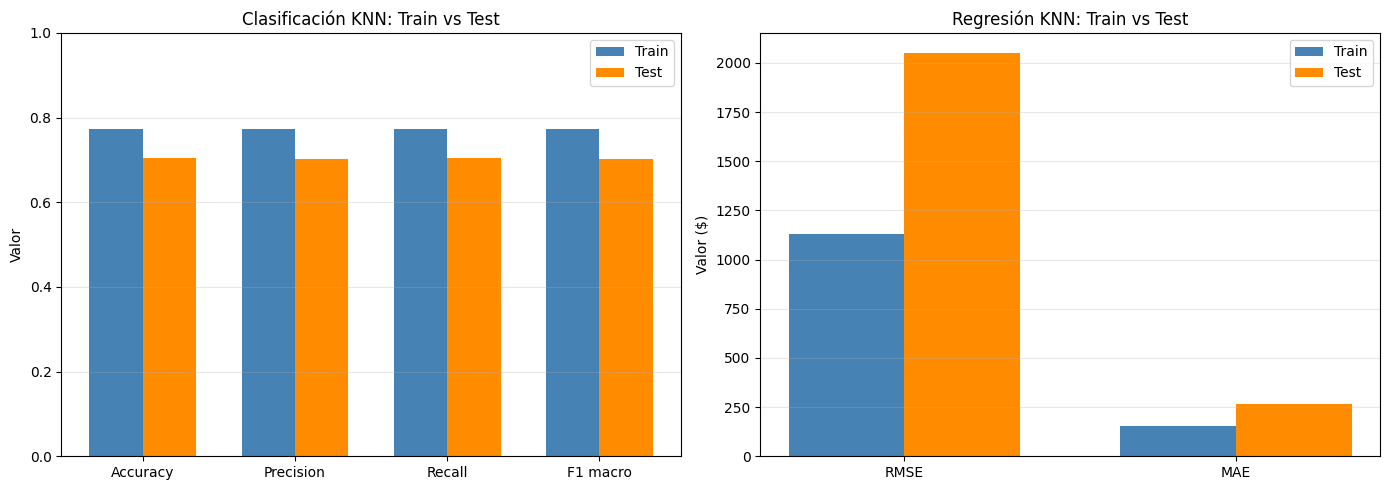


Diferencia en accuracy (train - test): 0.0700
Diferencia en F1 macro (train - test): 0.0703
Diferencia en R² (train - test): 0.1608


In [25]:
#Predicciones sobre el conjunto de entrenamiento
y_pred_train_class = knn_cls_pipeline.predict(X_train)
y_pred_train_reg = knn_reg_pipeline.predict(X_train)

#Métricas de clasificación: train vs test
acc_train = accuracy_score(y_train_class, y_pred_train_class)
f1_train = f1_score(y_train_class, y_pred_train_class, average="macro", zero_division=0)
prec_train = precision_score(y_train_class, y_pred_train_class, average="macro", zero_division=0)
rec_train = recall_score(y_train_class, y_pred_train_class, average="macro", zero_division=0)

acc_test = accuracy_knn_cls
f1_test = f1_knn_cls
prec_test = precision_knn_cls
rec_test = recall_knn_cls

overfit_cls_df = pd.DataFrame({
    "Métrica": ["Accuracy", "Precision macro", "Recall macro", "F1 macro"],
    "Train": [acc_train, prec_train, rec_train, f1_train],
    "Test": [acc_test, prec_test, rec_test, f1_test],
    "Diferencia": [acc_train - acc_test, prec_train - prec_test, rec_train - rec_test, f1_train - f1_test],
})

print("=== Clasificación KNN: Train vs Test ===")
display(overfit_cls_df.round(4))

#Métricas de regresión: train vs test
rmse_train = mean_squared_error(y_train_price, y_pred_train_reg) ** 0.5
mae_train = mean_absolute_error(y_train_price, y_pred_train_reg)
r2_train = r2_score(y_train_price, y_pred_train_reg)

overfit_reg_df = pd.DataFrame({
    "Métrica": ["RMSE", "MAE", "R²"],
    "Train": [rmse_train, mae_train, r2_train],
    "Test": [rmse_knn, mae_knn, r2_knn],
    "Diferencia": [rmse_train - rmse_knn, mae_train - mae_knn, r2_train - r2_knn],
})

print("\n=== Regresión KNN: Train vs Test ===")
display(overfit_reg_df.round(4))

#Gráfica comparativa
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics_cls = ["Accuracy", "Precision", "Recall", "F1 macro"]
train_vals_cls = [acc_train, prec_train, rec_train, f1_train]
test_vals_cls = [acc_test, prec_test, rec_test, f1_test]

x = np.arange(len(metrics_cls))
width = 0.35
axes[0].bar(x - width/2, train_vals_cls, width, label="Train", color="steelblue")
axes[0].bar(x + width/2, test_vals_cls, width, label="Test", color="darkorange")
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_cls)
axes[0].set_ylabel("Valor")
axes[0].set_title("Clasificación KNN: Train vs Test")
axes[0].legend()
axes[0].set_ylim(0, 1)
axes[0].grid(True, alpha=0.3, axis="y")

metrics_reg = ["RMSE", "MAE"]
train_vals_reg = [rmse_train, mae_train]
test_vals_reg = [rmse_knn, mae_knn]

x2 = np.arange(len(metrics_reg))
axes[1].bar(x2 - width/2, train_vals_reg, width, label="Train", color="steelblue")
axes[1].bar(x2 + width/2, test_vals_reg, width, label="Test", color="darkorange")
axes[1].set_xticks(x2)
axes[1].set_xticklabels(metrics_reg)
axes[1].set_ylabel("Valor ($)")
axes[1].set_title("Regresión KNN: Train vs Test")
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

print(f"\nDiferencia en accuracy (train - test): {acc_train - acc_test:.4f}")
print(f"Diferencia en F1 macro (train - test): {f1_train - f1_test:.4f}")
print(f"Diferencia en R² (train - test): {r2_train - r2_knn:.4f}")

**Conclusiones del inciso 7**

Sí, hay señales de sobreajuste, sobre todo en el modelo de regresión. En clasificación la diferencia entre train y test es de unos 7 puntos porcentuales en accuracy (0.7740 vs 0.7040) y en F1 macro (0.7725 vs 0.7022). Es una brecha moderada, el modelo se aprende los datos de entrenamiento un poco de más, pero no es algo exagerado.

Donde sí se nota más el problema es en regresión. El R² pasa de 0.9293 en entrenamiento a 0.7685 en prueba, y el RMSE casi se duplica (de 1,128 a 2,050). Esto nos dice que el modelo se ajusta muy bien a los precios que ya vio, pero cuando le toca predecir propiedades nuevas pierde bastante precisión. Es un comportamiento esperable con K=3, ya que con tan pocos vecinos el modelo es muy sensible a los puntos cercanos y captura ruido en lugar de patrones generales.

Para intentar reducir este sobreajuste, en el siguiente inciso vamos a usar validación cruzada, que nos da una estimación más confiable del rendimiento real del modelo y nos ayuda a elegir un K que generalice mejor.

## Inciso 8 – Modelo con validación cruzada

Para tener una estimación más confiable del rendimiento del KNN, usamos validación cruzada de 5 folds tanto para clasificación como para regresión. Esto nos permite evaluar qué tan estable es el modelo y comparar estos resultados con los del modelo anterior que solo usaba un split fijo de train/test.

In [ ]:
#Validación cruzada para clasificación (5 folds)
from sklearn.model_selection import cross_validate

knn_cls_cv_pipeline = Pipeline([
    ("preprocessor", knn_preprocessor),
    ("knn", KNeighborsClassifier(n_neighbors=best_k_cls, metric="minkowski", p=2)),
])

cv_cls_results = cross_validate(
    knn_cls_cv_pipeline,
    X_train, y_train_class,
    cv=5,
    scoring=["accuracy", "f1_macro", "precision_macro", "recall_macro"],
    return_train_score=True,
    n_jobs=-1,
)

cv_cls_df = pd.DataFrame({
    "Métrica": ["Accuracy", "Precision macro", "Recall macro", "F1 macro"],
    "CV Train (media)": [
        cv_cls_results["train_accuracy"].mean(),
        cv_cls_results["train_precision_macro"].mean(),
        cv_cls_results["train_recall_macro"].mean(),
        cv_cls_results["train_f1_macro"].mean(),
    ],
    "CV Test (media)": [
        cv_cls_results["test_accuracy"].mean(),
        cv_cls_results["test_precision_macro"].mean(),
        cv_cls_results["test_recall_macro"].mean(),
        cv_cls_results["test_f1_macro"].mean(),
    ],
    "CV Test (std)": [
        cv_cls_results["test_accuracy"].std(),
        cv_cls_results["test_precision_macro"].std(),
        cv_cls_results["test_recall_macro"].std(),
        cv_cls_results["test_f1_macro"].std(),
    ],
    "Test set (inciso anterior)": [acc_test, prec_test, rec_test, f1_test],
})

print("=== Clasificación KNN: Validación cruzada vs Test set ===")
display(cv_cls_df.round(4))

#Validación cruzada para regresión (5 folds)
knn_reg_cv_pipeline = Pipeline([
    ("preprocessor", knn_preprocessor),
    ("knn", KNeighborsRegressor(n_neighbors=best_k, metric="minkowski", p=2)),
])

cv_reg_results = cross_validate(
    knn_reg_cv_pipeline,
    X_train, y_train_price,
    cv=5,
    scoring=["neg_root_mean_squared_error", "neg_mean_absolute_error", "r2"],
    return_train_score=True,
    n_jobs=-1,
)

cv_reg_df = pd.DataFrame({
    "Métrica": ["RMSE", "MAE", "R²"],
    "CV Train (media)": [
        -cv_reg_results["train_neg_root_mean_squared_error"].mean(),
        -cv_reg_results["train_neg_mean_absolute_error"].mean(),
        cv_reg_results["train_r2"].mean(),
    ],
    "CV Test (media)": [
        -cv_reg_results["test_neg_root_mean_squared_error"].mean(),
        -cv_reg_results["test_neg_mean_absolute_error"].mean(),
        cv_reg_results["test_r2"].mean(),
    ],
    "CV Test (std)": [
        cv_reg_results["test_neg_root_mean_squared_error"].std(),
        cv_reg_results["test_neg_mean_absolute_error"].std(),
        cv_reg_results["test_r2"].std(),
    ],
    "Test set (inciso anterior)": [rmse_knn, mae_knn, r2_knn],
})

print("\n=== Regresión KNN: Validación cruzada vs Test set ===")
display(cv_reg_df.round(4))

#Gráfica comparativa
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics_cls_names = ["Accuracy", "Precision", "Recall", "F1 macro"]
cv_vals = cv_cls_df["CV Test (media)"].values
test_vals = cv_cls_df["Test set (inciso anterior)"].values

x = np.arange(len(metrics_cls_names))
width = 0.35
axes[0].bar(x - width/2, cv_vals, width, label="CV (media)", color="seagreen")
axes[0].bar(x + width/2, test_vals, width, label="Test set", color="darkorange")
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_cls_names)
axes[0].set_ylabel("Valor")
axes[0].set_title("Clasificación: CV vs Test set")
axes[0].legend()
axes[0].set_ylim(0, 1)
axes[0].grid(True, alpha=0.3, axis="y")

metrics_reg_names = ["RMSE", "MAE"]
cv_reg_vals = cv_reg_df["CV Test (media)"].values[:2]
test_reg_vals = cv_reg_df["Test set (inciso anterior)"].values[:2]

x2 = np.arange(len(metrics_reg_names))
axes[1].bar(x2 - width/2, cv_reg_vals, width, label="CV (media)", color="seagreen")
axes[1].bar(x2 + width/2, test_reg_vals, width, label="Test set", color="darkorange")
axes[1].set_xticks(x2)
axes[1].set_xticklabels(metrics_reg_names)
axes[1].set_ylabel("Valor ($)")
axes[1].set_title("Regresión: CV vs Test set")
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

**Conclusiones del inciso 8**

La validación cruzada confirma que los resultados del modelo son estables y no dependen de un split afortunado. En clasificación, el F1 macro por CV fue de 0.7010, prácticamente igual al 0.7022 del test set, con una desviación estándar de apenas 0.0035. Esto nos dice que el modelo se comporta de forma consistente sin importar cómo se dividan los datos.

En regresión, la validación cruzada nos dio un panorama un poco más optimista que el test set: el R² por CV fue 0.8119 vs 0.7685 en el test set, y el RMSE por CV fue 1,831 vs 2,050 en test. La desviación estándar del R² en CV (0.0286) muestra que hay cierta variabilidad entre folds, pero nada alarmante.

Lo interesante es que la validación cruzada nos ayuda a confirmar el sobreajuste que notamos en el inciso anterior, pero de forma más matizada. La brecha entre CV train (0.9182) y CV test (0.8119) en R² sigue siendo considerable, lo que refuerza que el modelo con K=3 memoriza parte de los datos. Sin embargo, el modelo con validación cruzada funcionó ligeramente mejor que el modelo evaluado solo en el test set, lo que sugiere que el split fijo del test set puede ser un poco más difícil que el promedio de los folds.

## Inciso 9 – Tuneo de hiperparámetros

In [28]:
#Tuneo de hiperparámetros para REGRESIÓN
param_grid_reg = {
    "knn__n_neighbors": [3, 5, 7, 11, 15, 21],
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["minkowski"],
    "knn__p": [1, 2],
}

grid_reg = GridSearchCV(
    Pipeline([
        ("preprocessor", knn_preprocessor),
        ("knn", KNeighborsRegressor()),
    ]),
    param_grid_reg,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1,
)

print("Tuneando KNN de regresión...")
start = time.time()
grid_reg.fit(X_train, y_train_price)
tuning_time_reg = time.time() - start
print(f"Tiempo de tuneo: {tuning_time_reg:.1f}s")

print(f"\nMejores hiperparámetros (regresión): {grid_reg.best_params_}")
print(f"Mejor RMSE (CV): {-grid_reg.best_score_:.2f}")

#Predicciones con el mejor modelo tuneado
y_pred_tuned_reg = grid_reg.best_estimator_.predict(X_test)
rmse_tuned = mean_squared_error(y_test_price, y_pred_tuned_reg) ** 0.5
mae_tuned = mean_absolute_error(y_test_price, y_pred_tuned_reg)
r2_tuned = r2_score(y_test_price, y_pred_tuned_reg)

print(f"\nResultados en test set (modelo tuneado):")
print(f"  RMSE: {rmse_tuned:.2f}")
print(f"  MAE:  {mae_tuned:.2f}")
print(f"  R²:   {r2_tuned:.4f}")

#Comparación con modelo original
tuning_reg_comparison = pd.DataFrame([
    {"Modelo": f"KNN original (K={best_k})", "RMSE": rmse_knn, "MAE": mae_knn, "R²": r2_knn},
    {"Modelo": "KNN tuneado", "RMSE": rmse_tuned, "MAE": mae_tuned, "R²": r2_tuned},
])
print("\nComparación regresión:")
display(tuning_reg_comparison.round(4))

#Top 10 combinaciones
results_reg_df = pd.DataFrame(grid_reg.cv_results_)
results_reg_df["RMSE_CV"] = -results_reg_df["mean_test_score"]
top10_reg = results_reg_df.nsmallest(10, "RMSE_CV")[
    ["param_knn__n_neighbors", "param_knn__weights", "param_knn__p", "RMSE_CV", "std_test_score"]
].reset_index(drop=True)
top10_reg.columns = ["K", "Weights", "P", "RMSE (CV)", "Std"]
print("\nTop 10 combinaciones (regresión):")
display(top10_reg.round(4))

Tuneando KNN de regresión...
Fitting 3 folds for each of 24 candidates, totalling 72 fits
Tiempo de tuneo: 2629.1s

Mejores hiperparámetros (regresión): {'knn__metric': 'minkowski', 'knn__n_neighbors': 5, 'knn__p': 1, 'knn__weights': 'distance'}
Mejor RMSE (CV): 1539.79

Resultados en test set (modelo tuneado):
  RMSE: 1783.16
  MAE:  221.06
  R²:   0.8250

Comparación regresión:


,Modelo,RMSE,MAE,R²
0,KNN original (K=3),2050.7985,264.4580,0.7685
1,KNN tuneado,1783.1634,221.0613,0.8250



Top 10 combinaciones (regresión):


,K,Weights,P,RMSE (CV),Std
0,5,distance,1,1539.7870,104.2106
1,3,distance,1,1567.2341,101.6966
2,7,distance,1,1584.1933,86.2044
3,11,distance,1,1622.7165,54.5356
4,15,distance,1,1654.7386,48.9896
5,3,uniform,1,1658.9459,108.7054
6,5,uniform,1,1678.1024,104.2460
7,21,distance,1,1712.9980,35.0406
8,3,distance,2,1760.2740,85.1532
9,5,distance,2,1769.6922,44.3993


Tuneando KNN de clasificación...
Fitting 3 folds for each of 24 candidates, totalling 72 fits
Tiempo de tuneo: 1543.3s

Mejores hiperparámetros (clasificación): {'knn__metric': 'minkowski', 'knn__n_neighbors': 15, 'knn__p': 1, 'knn__weights': 'distance'}
Mejor F1 macro (CV): 0.7351

Resultados en test set (modelo tuneado):
  Accuracy:        0.7430
  Precision macro: 0.7434
  Recall macro:    0.7436
  F1 macro:        0.7433

Comparación clasificación:


,Modelo,Accuracy,Precision macro,Recall macro,F1 macro
0,KNN original (K=9),0.704,0.7021,0.7049,0.7022
1,KNN tuneado,0.743,0.7434,0.7436,0.7433



Top 10 combinaciones (clasificación):


,K,Weights,P,F1 macro (CV),Std
0,15,distance,1,0.7351,0.0032
1,11,distance,1,0.7348,0.0025
2,21,distance,1,0.7344,0.0036
3,7,distance,1,0.7310,0.0023
4,5,distance,1,0.7251,0.0032
5,3,distance,1,0.7161,0.0050
6,15,distance,2,0.7089,0.0029
7,21,distance,2,0.7084,0.0037
8,11,distance,2,0.7075,0.0032
9,7,distance,2,0.7057,0.0029


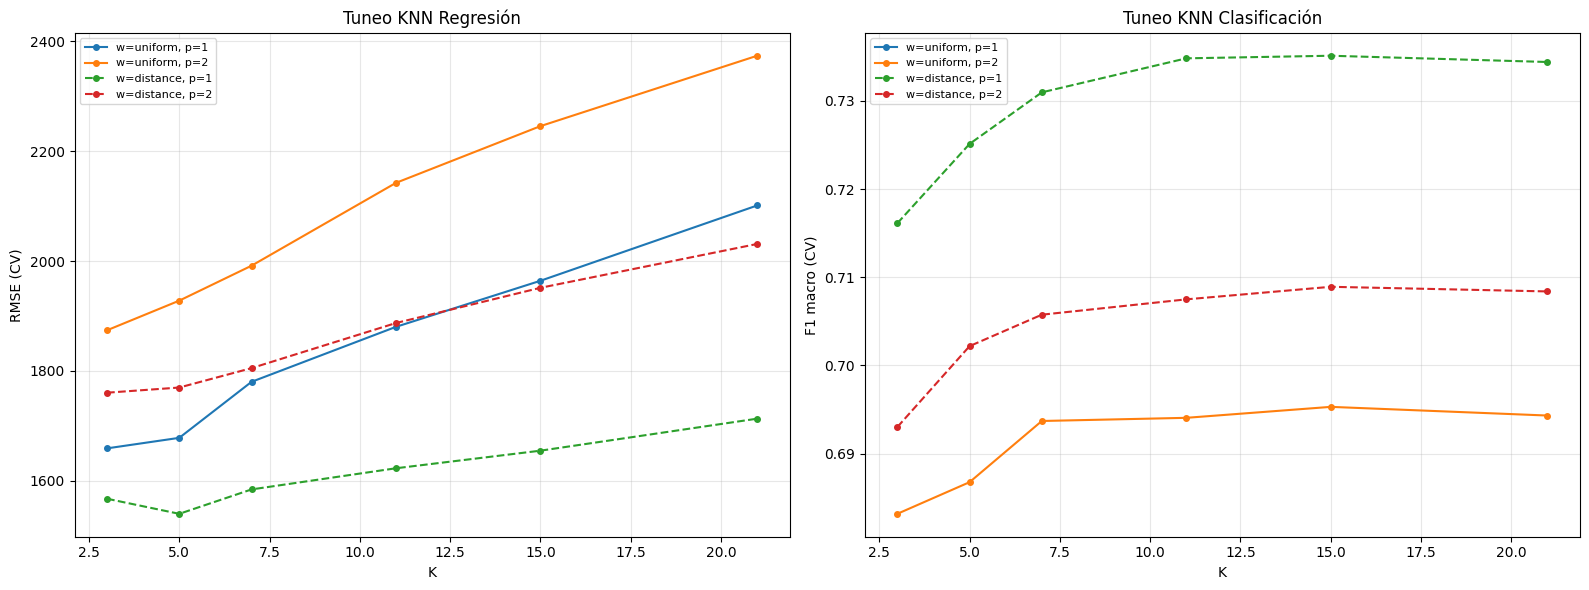

In [29]:
#Tuneo de hiperparámetros para CLASIFICACIÓN
param_grid_cls = {
    "knn__n_neighbors": [3, 5, 7, 11, 15, 21],
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["minkowski"],
    "knn__p": [1, 2],
}

grid_cls = GridSearchCV(
    Pipeline([
        ("preprocessor", knn_preprocessor),
        ("knn", KNeighborsClassifier()),
    ]),
    param_grid_cls,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1,
)

print("Tuneando KNN de clasificación...")
start = time.time()
grid_cls.fit(X_train, y_train_class)
tuning_time_cls = time.time() - start
print(f"Tiempo de tuneo: {tuning_time_cls:.1f}s")

print(f"\nMejores hiperparámetros (clasificación): {grid_cls.best_params_}")
print(f"Mejor F1 macro (CV): {grid_cls.best_score_:.4f}")

#Predicciones con el mejor modelo tuneado
y_pred_tuned_cls = grid_cls.best_estimator_.predict(X_test)
acc_tuned = accuracy_score(y_test_class, y_pred_tuned_cls)
prec_tuned = precision_score(y_test_class, y_pred_tuned_cls, average="macro", zero_division=0)
rec_tuned = recall_score(y_test_class, y_pred_tuned_cls, average="macro", zero_division=0)
f1_tuned = f1_score(y_test_class, y_pred_tuned_cls, average="macro", zero_division=0)

print(f"\nResultados en test set (modelo tuneado):")
print(f"  Accuracy:        {acc_tuned:.4f}")
print(f"  Precision macro: {prec_tuned:.4f}")
print(f"  Recall macro:    {rec_tuned:.4f}")
print(f"  F1 macro:        {f1_tuned:.4f}")

#Comparación con modelo original
tuning_cls_comparison = pd.DataFrame([
    {"Modelo": f"KNN original (K={best_k_cls})", "Accuracy": acc_test, "Precision macro": prec_test, "Recall macro": rec_test, "F1 macro": f1_test},
    {"Modelo": "KNN tuneado", "Accuracy": acc_tuned, "Precision macro": prec_tuned, "Recall macro": rec_tuned, "F1 macro": f1_tuned},
])
print("\nComparación clasificación:")
display(tuning_cls_comparison.round(4))

#Top 10 combinaciones
results_cls_df = pd.DataFrame(grid_cls.cv_results_)
top10_cls = results_cls_df.nlargest(10, "mean_test_score")[
    ["param_knn__n_neighbors", "param_knn__weights", "param_knn__p", "mean_test_score", "std_test_score"]
].reset_index(drop=True)
top10_cls.columns = ["K", "Weights", "P", "F1 macro (CV)", "Std"]
print("\nTop 10 combinaciones (clasificación):")
display(top10_cls.round(4))

#Gráfica de resultados del tuneo
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for weight in ["uniform", "distance"]:
    for p_val in [1, 2]:
        mask = (results_reg_df["param_knn__weights"] == weight) & (results_reg_df["param_knn__p"] == p_val)
        subset = results_reg_df[mask].sort_values("param_knn__n_neighbors")
        label = f"w={weight}, p={p_val}"
        linestyle = "-" if weight == "uniform" else "--"
        axes[0].plot(subset["param_knn__n_neighbors"], subset["RMSE_CV"], marker="o", label=label, linestyle=linestyle, markersize=4)

axes[0].set_xlabel("K")
axes[0].set_ylabel("RMSE (CV)")
axes[0].set_title("Tuneo KNN Regresión")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

for weight in ["uniform", "distance"]:
    for p_val in [1, 2]:
        mask = (results_cls_df["param_knn__weights"] == weight) & (results_cls_df["param_knn__p"] == p_val)
        subset = results_cls_df[mask].sort_values("param_knn__n_neighbors")
        label = f"w={weight}, p={p_val}"
        linestyle = "-" if weight == "uniform" else "--"
        axes[1].plot(subset["param_knn__n_neighbors"], subset["mean_test_score"], marker="o", label=label, linestyle=linestyle, markersize=4)

axes[1].set_xlabel("K")
axes[1].set_ylabel("F1 macro (CV)")
axes[1].set_title("Tuneo KNN Clasificación")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Conclusiones del inciso 9**

El tuneo de hiperparámetros mejoró bastante ambos modelos respecto a la versión original.

En **regresión**, el modelo original con K=3 tenía un RMSE de 2,050 y R² de 0.7685. El modelo tuneado (K=5, weights=distance, p=1) bajó el RMSE a 1,783 y subió el R² a 0.8250. Eso es una mejora importante: el error promedio se redujo en unos $267 por predicción y el modelo ahora explica el 82.5% de la variabilidad del precio.

En **clasificación**, la mejora también fue clara. El modelo original con K=9 tenía un F1 macro de 0.7022, mientras que el tuneado (K=15, weights=distance, p=1) lo subió a 0.7433. El accuracy pasó de 0.704 a 0.743, lo que significa que ahora clasifica correctamente unas 4 de cada 100 propiedades más.

Un patrón muy claro que se ve en las tablas de top 10 es que la combinación ganadora siempre es **weights=distance** con **p=1** (Manhattan). Todas las mejores combinaciones en ambas tareas comparten estos dos valores. Usar pesos por distancia le permite al modelo darle más importancia a los vecinos que están realmente cerca, y la distancia Manhattan funciona mejor porque es más robusta cuando hay muchas variables (después del one-hot encoding tenemos cientos de columnas).

## Inciso 10 – Métrica de distancia y valor de P

**¿Qué métrica de distancia resultó mejor?**

La distancia **Manhattan (Minkowski con p=1)** fue la mejor en ambos modelos. Se puede ver claramente en los resultados del tuneo: las 7 mejores combinaciones en regresión y las 6 mejores en clasificación usan p=1. La distancia Euclidiana (p=2) quedó consistentemente por debajo.

**¿Qué valor de P resultó mejor?**

P=1 fue el ganador. En la fórmula de Minkowski, cuando p=1 la distancia se calcula sumando las diferencias absolutas entre cada variable (Manhattan), y cuando p=2 se suman los cuadrados y se saca raíz (Euclidiana). El valor p=1 resultó mejor en todos los escenarios probados.

**¿Por qué estas métricas son las más adecuadas para este modelo?**

Hay varias razones por las que la distancia Manhattan con pesos por distancia funciona mejor en nuestro caso:

1. **Alta dimensionalidad:** después del one-hot encoding de las variables categóricas, el espacio de variables tiene cientos de dimensiones. En espacios de muchas dimensiones, la distancia Euclidiana tiende a perder sentido porque las diferencias se diluyen. La distancia Manhattan es más robusta en estos casos porque no eleva al cuadrado las diferencias, evitando que una sola variable con un valor atípico domine toda la distancia.

2. **Variables binarias del OHE:** muchas de nuestras variables después del encoding son 0 o 1. Con Manhattan, la diferencia entre dos propiedades en una variable binaria siempre es 0 o 1, lo cual es más interpretable. Con Euclidiana, esa diferencia se eleva al cuadrado pero sigue siendo 0 o 1, así que en teoría no cambia mucho, pero el efecto acumulado con todas las demás variables sí marca diferencia.

3. **Pesos por distancia (weights=distance):** este hiperparámetro le da más peso a los vecinos más cercanos. Es decir, si de los K vecinos hay 2 que están muy cerca y 3 que están más lejos, los cercanos pesan más en la predicción. Esto tiene sentido porque en un mercado de propiedades, las que son más parecidas en características deberían tener precios más similares.

4. **Outliers en precios:** nuestro dataset tiene propiedades con precios muy altos. La distancia Manhattan es menos sensible a estos valores extremos porque no los amplifica al cuadrado como lo hace la Euclidiana.

## Inciso 11 – Comparación con modelos de clasificación de entregas pasadas

Comparamos el mejor modelo de clasificación KNN (tuneado) con los mejores modelos de clasificación de las entregas anteriores: Árbol de Decisión y Random Forest (lab 4), y Naive Bayes (lab 5). Para que la comparación sea justa, entrenamos todos los modelos con el mismo conjunto de entrenamiento y prueba de este notebook.

Entrenando Árbol de Decisión...
  Accuracy: 0.7132 | Tiempo train: 1.67s | Tiempo pred: 0.05s
Entrenando Random Forest...
  Accuracy: 0.7198 | Tiempo train: 0.93s | Tiempo pred: 0.10s
Entrenando Naive Bayes...
  Accuracy: 0.5957 | Tiempo train: 0.90s | Tiempo pred: 0.22s

=== Comparación de modelos de clasificación (mismo train/test) ===


,Modelo,Accuracy,Precision macro,Recall macro,F1 macro,Tiempo train (s),Tiempo pred (s)
0,"KNN tuneado (K=15, p=1, distance)",0.7430,0.7434,0.7436,0.7433,1543.2743,0.0000
1,Random Forest (lab4),0.7198,0.7145,0.7207,0.7146,0.9265,0.0973
2,Árbol de Decisión (lab4),0.7132,0.7129,0.7139,0.7130,1.6725,0.0475
3,Naive Bayes (lab5),0.5957,0.5928,0.5966,0.5940,0.8962,0.2157



Mejor modelo según F1 macro: KNN tuneado (K=15, p=1, distance)


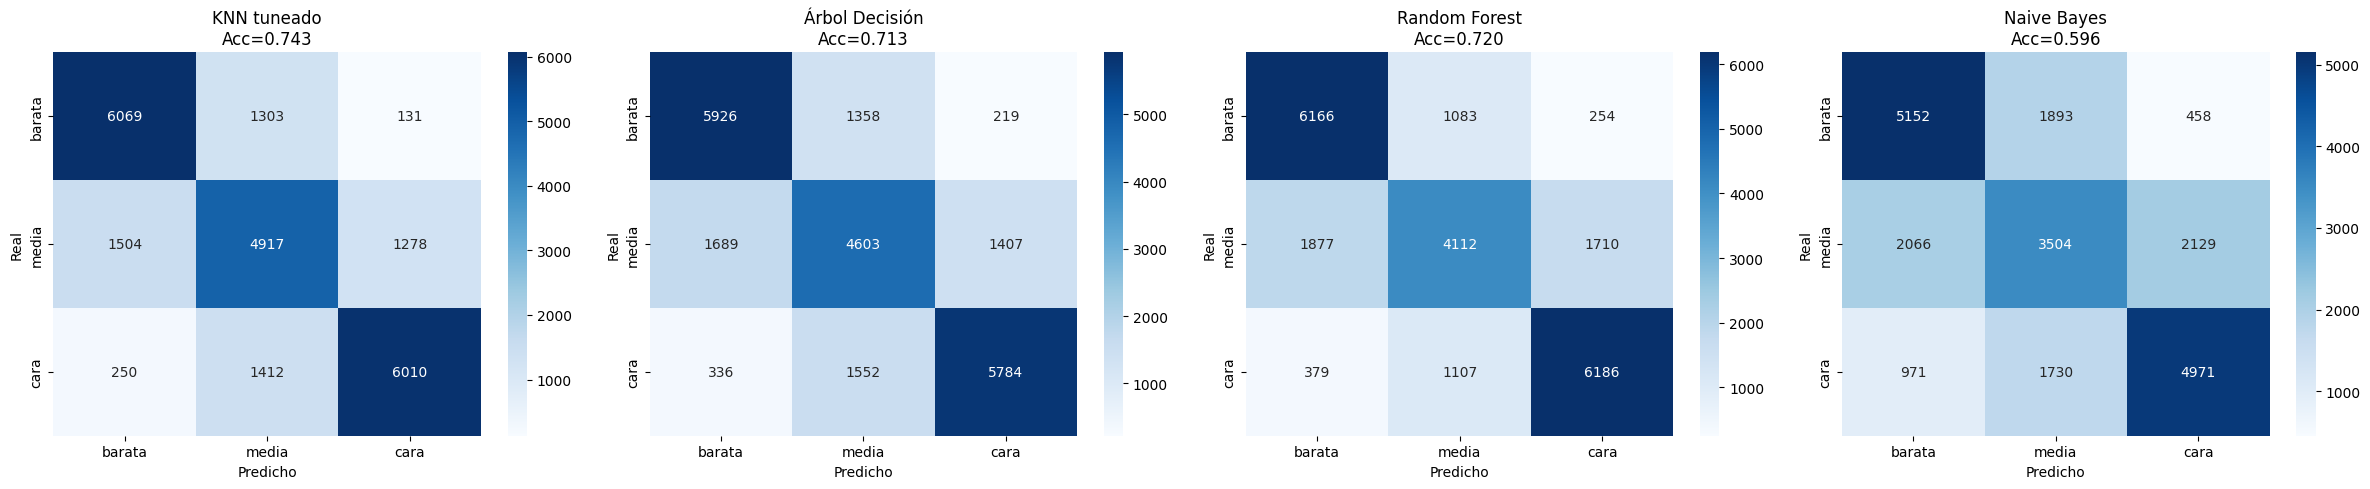

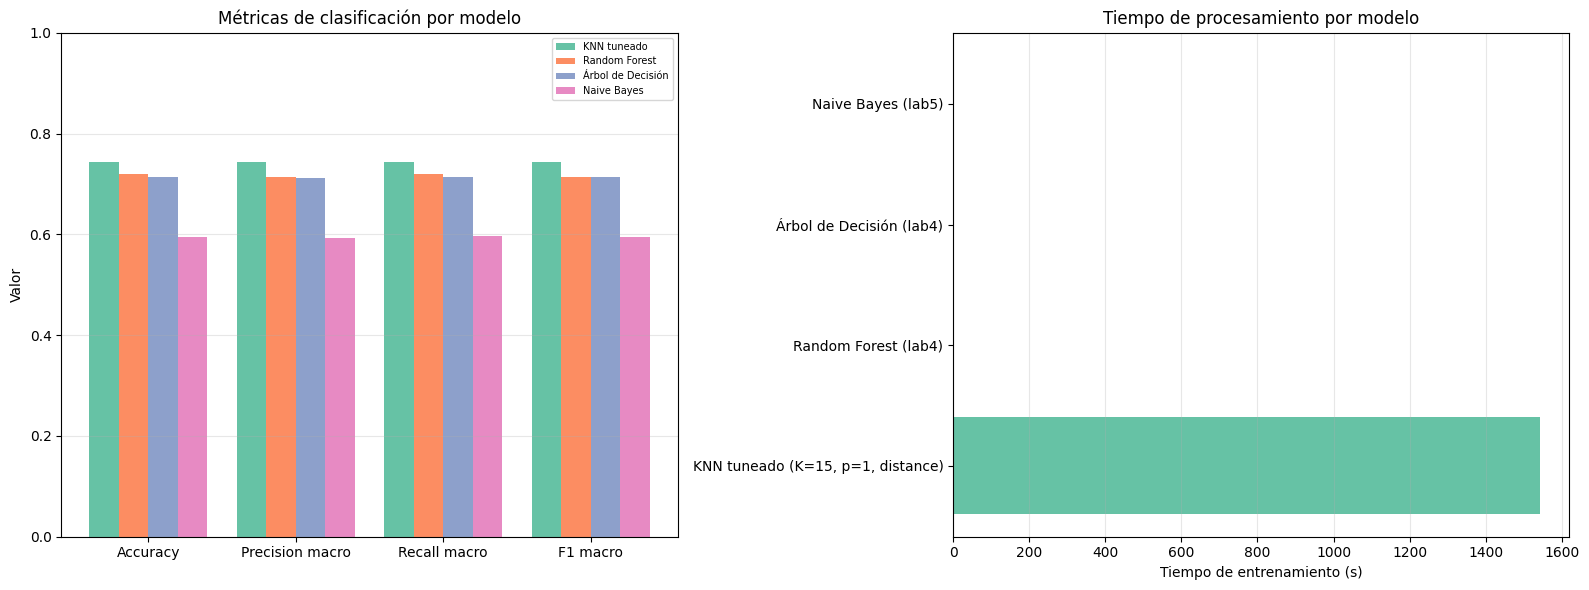

In [30]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import BernoulliNB

#Árbol de Decisión (mismos hiperparámetros tuneados del lab4)
print("Entrenando Árbol de Decisión...")
pipeline_dt_cls = Pipeline([
    ("preprocessor", common_preprocessor),
    ("clf", DecisionTreeClassifier(max_depth=15, min_samples_leaf=10, min_samples_split=10, random_state=42)),
])
start = time.time()
pipeline_dt_cls.fit(X_train, y_train_class)
time_dt_train = time.time() - start

start = time.time()
y_pred_dt_cls = pipeline_dt_cls.predict(X_test)
time_dt_pred = time.time() - start
print(f"  Accuracy: {accuracy_score(y_test_class, y_pred_dt_cls):.4f} | Tiempo train: {time_dt_train:.2f}s | Tiempo pred: {time_dt_pred:.2f}s")

#Random Forest (mismos hiperparámetros del lab4)
print("Entrenando Random Forest...")
pipeline_rf_cls = Pipeline([
    ("preprocessor", common_preprocessor),
    ("clf", RandomForestClassifier(n_estimators=200, max_depth=15, min_samples_leaf=5, random_state=42, n_jobs=-1)),
])
start = time.time()
pipeline_rf_cls.fit(X_train, y_train_class)
time_rf_train = time.time() - start

start = time.time()
y_pred_rf_cls = pipeline_rf_cls.predict(X_test)
time_rf_pred = time.time() - start
print(f"  Accuracy: {accuracy_score(y_test_class, y_pred_rf_cls):.4f} | Tiempo train: {time_rf_train:.2f}s | Tiempo pred: {time_rf_pred:.2f}s")

#Naive Bayes (mismos hiperparámetros tuneados del lab5)
print("Entrenando Naive Bayes...")
nb_cls_preprocessor = ColumnTransformer([
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]), categorical_columns),
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("kbins", KBinsDiscretizer(n_bins=5, encode="ordinal", strategy="quantile")),
    ]), numerical_columns),
])

pipeline_nb_cls = Pipeline([
    ("preprocessor", nb_cls_preprocessor),
    ("clf", BernoulliNB(alpha=0.01, binarize=0.0)),
])
start = time.time()
pipeline_nb_cls.fit(X_train, y_train_class)
time_nb_train = time.time() - start

start = time.time()
y_pred_nb_cls = pipeline_nb_cls.predict(X_test)
time_nb_pred = time.time() - start
print(f"  Accuracy: {accuracy_score(y_test_class, y_pred_nb_cls):.4f} | Tiempo train: {time_nb_train:.2f}s | Tiempo pred: {time_nb_pred:.2f}s")

#Tabla comparativa final
all_models_cls = []
models_preds = {
    "KNN tuneado (K=15, p=1, distance)": (y_pred_tuned_cls, tuning_time_cls, None),
    "Árbol de Decisión (lab4)": (y_pred_dt_cls, time_dt_train, time_dt_pred),
    "Random Forest (lab4)": (y_pred_rf_cls, time_rf_train, time_rf_pred),
    "Naive Bayes (lab5)": (y_pred_nb_cls, time_nb_train, time_nb_pred),
}

for name, (y_pred, t_train, t_pred) in models_preds.items():
    all_models_cls.append({
        "Modelo": name,
        "Accuracy": accuracy_score(y_test_class, y_pred),
        "Precision macro": precision_score(y_test_class, y_pred, average="macro", zero_division=0),
        "Recall macro": recall_score(y_test_class, y_pred, average="macro", zero_division=0),
        "F1 macro": f1_score(y_test_class, y_pred, average="macro", zero_division=0),
        "Tiempo train (s)": t_train,
        "Tiempo pred (s)": t_pred if t_pred else 0,
    })

comparison_cls_df = pd.DataFrame(all_models_cls).sort_values("F1 macro", ascending=False).reset_index(drop=True)
print("\n=== Comparación de modelos de clasificación (mismo train/test) ===")
display(comparison_cls_df.round(4))

best_cls_model = comparison_cls_df.iloc[0]["Modelo"]
print(f"\nMejor modelo según F1 macro: {best_cls_model}")

#Matrices de confusión de todos los modelos
fig, axes = plt.subplots(1, 4, figsize=(24, 5))
models_for_cm = {
    "KNN tuneado": y_pred_tuned_cls,
    "Árbol Decisión": y_pred_dt_cls,
    "Random Forest": y_pred_rf_cls,
    "Naive Bayes": y_pred_nb_cls,
}

for ax, (name, y_pred) in zip(axes, models_for_cm.items()):
    cm = confusion_matrix(y_test_class, y_pred, labels=labels_order)
    sns.heatmap(pd.DataFrame(cm, index=labels_order, columns=labels_order),
                annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(f"{name}\nAcc={accuracy_score(y_test_class, y_pred):.3f}")
    ax.set_xlabel("Predicho")
    ax.set_ylabel("Real")

plt.tight_layout()
plt.show()

#Gráfica comparativa de métricas
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

modelos_names = comparison_cls_df["Modelo"].values
colores = sns.color_palette("Set2", n_colors=len(modelos_names))

metrics_to_plot = ["Accuracy", "Precision macro", "Recall macro", "F1 macro"]
x = np.arange(len(metrics_to_plot))
width = 0.2

for i, (_, row) in enumerate(comparison_cls_df.iterrows()):
    vals = [row[m] for m in metrics_to_plot]
    axes[0].bar(x + i * width, vals, width, label=row["Modelo"].split("(")[0].strip(), color=colores[i])

axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(metrics_to_plot)
axes[0].set_ylabel("Valor")
axes[0].set_title("Métricas de clasificación por modelo")
axes[0].legend(fontsize=7)
axes[0].set_ylim(0, 1)
axes[0].grid(True, alpha=0.3, axis="y")

axes[1].barh(modelos_names, comparison_cls_df["Tiempo train (s)"].values, color=colores)
axes[1].set_xlabel("Tiempo de entrenamiento (s)")
axes[1].set_title("Tiempo de procesamiento por modelo")
axes[1].grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.show()

**Conclusiones del inciso 11**

El **KNN tuneado** es el mejor modelo de clasificación de todas las entregas, con un F1 macro de 0.7433 y accuracy de 0.743. Supera al Random Forest (0.7146), al Árbol de Decisión (0.7130) y por bastante al Naive Bayes (0.5940).

Si miramos las matrices de confusión, el KNN tuneado es el que mejor clasifica las tres categorías de forma equilibrada. En particular, clasifica mejor la categoría "cara" (6,010 aciertos vs 5,784 del Árbol y 6,186 del RF) y mantiene un buen balance con "barata" (6,069 aciertos). La categoría "media" sigue siendo la más difícil para todos los modelos, pero el KNN la maneja mejor que los demás (4,917 aciertos vs 4,603 del Árbol y 4,112 del RF).

En cuanto a tiempos, el KNN es por mucho el más lento. Su tiempo de "entrenamiento" reportado (1,543 segundos) incluye todo el proceso de tuneo con GridSearchCV, que prueba múltiples combinaciones de hiperparámetros. En comparación, los otros modelos entrenan en menos de 2 segundos. Esto es una desventaja importante del KNN: es un algoritmo "lazy" que no aprende un modelo como tal, sino que guarda todos los datos y calcula distancias en el momento de predecir. Por eso también la predicción es más lenta (aunque en este caso no se nota tanto).

Si SmartStay necesita un modelo que clasifique con la mayor precisión posible y el tiempo de procesamiento no es un problema, el KNN tuneado es la mejor opción. Si necesita respuestas rápidas y un buen balance entre velocidad y precisión, el Random Forest sigue siendo una alternativa muy sólida con métricas apenas por debajo del KNN pero con un entrenamiento casi instantáneo.